# ECC Forward Model — Benchmark Study

**Goal**: Defend the choice of CatBoost + Mondrian CQR as the production forward model
through four empirical analyses:

- **Part 1** — Point-accuracy benchmark (MAE / RMSE / R²) across 7 backends
- **Part 2** — Mondrian CQR regime-wise coverage & width across all backends
- **Part 3** — CatBoost calibration ablation: Plain QR vs CQR vs Mondrian CQR
- **Part 4** — Alpha sweep: calibration honesty across risk levels

**Dataset**: 620 specimens → 276 group-mean compositions (age-filtered, 13-col fingerprint),
37 engineered features, targets = Second Stress (MPa) & Second Strain.

**Fair-comparison principle**: Every backend is wrapped in the same Mondrian CQR layer,
isolating predictive quality from calibration mechanism.


In [17]:
!pip install catboost xgboost scikit-learn torch optuna scipy quantile-forest --quiet

# Pinned versions used during development:
# catboost==1.2.10   xgboost>=2.0.0   scikit-learn>=1.4   torch>=2.0
# optuna>=3.0        scipy>=1.10      quantile-forest>=1.3

In [18]:
import os, re, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

# ── Seeds (non-negotiable: every RNG uses SEED=42) ────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────
EXCEL_PATH   = "/Users/adityagk/Desktop/UniRGV_internship/ECC/data/Tension Test_VIT_re.xlsx"
SHEET_NAME   = "Tension Test_VIT"
RESULTS_DIR  = Path("results/benchmark")
OPTUNA_DIR   = RESULTS_DIR / "optuna_studies"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OPTUNA_DIR.mkdir(exist_ok=True)

# ── Targets and regime definitions (exact cutoffs from production pipeline) ──
TARGETS = ["Second Stress", "Second Strain"]
REGIME_CUTOFFS = {
    "Second Strain": (0.005, 0.050),
    "Second Stress": (4.0,   5.13),
}
REGIME_NAMES = {
    "Second Strain": ("NoPSH", "Bulk",  "Tail"),
    "Second Stress": ("Weak",  "Mid",   "Strong"),
}

# ── CV config ─────────────────────────────────────────────────────────────
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 3
ALPHA_DEFAULT = 0.20          # 80% prediction intervals
FIT_CAL_RATIO = 0.75          # 75% fit, 25% calibration inside each outer fold
EPS = 1e-8

# ── Optuna trial budgets ───────────────────────────────────────────────────
# CatBoost uses production HPs from ECC_Pipeline_Combined.ipynb (already tuned)
CATBOOST_HP = {
    "Second Stress": {
        "iterations": 800,
        "depth": 10,
        "learning_rate": 0.03156119992394155,
        "l2_leaf_reg": 0.20410490729823838,
        "random_seed": SEED,
        "verbose": 0,
    },
    "Second Strain": {
        "iterations": 600,
        "depth": 9,
        "learning_rate": 0.12604670759479358,
        "l2_leaf_reg": 0.2919794366938302,
        "random_seed": SEED,
        "verbose": 0,
    },
}

N_TRIALS = {
    "CatBoost":      0,   # pre-tuned; fixed HPs from ECC_Pipeline_Combined.ipynb
    "XGBoost":      40,   # reduced from 100 — good quality at lower cost
    "RandomForest":  50,
    "ExtraTrees":    50,
    "Ridge":          0,   # fixed linear baseline — no tuning
    "SVR":           20,   # RBF-kernel quantile; C + gamma search
}
# CatBoost last — other models run first with full Optuna search
MODEL_NAMES = ["Ridge", "SVR", "XGBoost", "RandomForest", "ExtraTrees", "CatBoost"]

# ── Optional dependency checks ─────────────────────────────────────────────
try:
    import xgboost as xgb
    XGB_VERSION = tuple(int(x) for x in xgb.__version__.split(".")[:2])
    XGB_AVAILABLE = XGB_VERSION >= (2, 0)
    if not XGB_AVAILABLE:
        print(f"WARNING: XGBoost {xgb.__version__} < 2.0. reg:quantileerror not available.")
except ImportError:
    XGB_AVAILABLE = False; print("WARNING: XGBoost not installed.")

try:
    import torch
    import torch.nn as nn
    import torch.optim as torch_optim
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False; print("WARNING: PyTorch not installed — ANN will be skipped.")

try:
    from quantile_forest import RandomForestQuantileRegressor, ExtraTreesQuantileRegressor
    QFOREST_AVAILABLE = True
except ImportError:
    QFOREST_AVAILABLE = False
    print("WARNING: quantile-forest not installed — RF/ET will use tree-variance quantiles.")


from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

print("Imports complete.")


Imports complete.


In [19]:
# ─── Preprocessing ────────────────────────────────────────────────────────
raw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
raw = raw.rename(columns={"Water Reducer / SP": "Water Reducer/SP"})
df  = raw.copy()


def extract_age(row):
    for col in ["Specimen", "Mixture"]:
        v = str(row.get(col, ""))
        m = re.search(r"(\d+)\s*[dD]", v)
        if m:
            return int(m.group(1))
    return None


ages      = df.apply(extract_age, axis=1)
mask_drop = ages.notna() & (ages < 28)
df        = df[~mask_drop].reset_index(drop=True)

# 13-column group fingerprint
GROUP_COLS = [
    "Fiber Volume", "L/D", "RI", "Cement", "Water", "Sand",
    "Fly ash C", "Fly ash F", "GGBS", "Coarse Aggr.",
    "Silica Fume", "Water Reducer/SP", "W/B",
]
for c in GROUP_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median() if df[c].dropna().size else 0)

df["_fp"]     = df[GROUP_COLS].round(4).apply(lambda r: "|".join(map(str, r.values)), axis=1)
df["group_id"] = pd.factorize(df["_fp"])[0]

# Derived binder quantities
df["Binder"]           = df["Cement"] + df["Fly ash F"] + df["Fly ash C"] + df["GGBS"] + df["Silica Fume"]
df["Paste"]            = df["Binder"] + df["Water"]
df["Total_Aggregates"] = df["Sand"]   + df["Coarse Aggr."]

# Engineered features (Group A, B, C — 19 features)
df["FA/Binder Ratio"]     = (df["Fly ash F"] + df["Fly ash C"]) / (df["Binder"] + EPS)
df["S/B Ratio"]           = df["Sand"]   / (df["Binder"] + EPS)
df["Paste Volume"]        = df["Paste"]
df["SCM Ratio"]           = (df["Fly ash F"] + df["Fly ash C"] + df["GGBS"] + df["Silica Fume"]) / (df["Cement"] + EPS)
df["Aggregate Ratio"]     = df["Total_Aggregates"] / (df["Paste"] + EPS)
df["Fiber Surface Area"]  = df["Fiber Volume"] * (df["Length (mm)"] / (df["Diameter (mm)"] + EPS))
df["Fiber Efficiency"]    = df["Fiber Volume"] * df["L/D"]
df["GGBS Presence"]       = (df["GGBS"]         > 0).astype(int)
df["Silica Fume Presence"]= (df["Silica Fume"]  > 0).astype(int)
df["Coarse Agg Presence"] = (df["Coarse Aggr."] > 0).astype(int)
df["tau_proxy"]           = 1.0 / (df["W/B"] + EPS)
df["Flaw Size Proxy"]     = df["Aggregate Ratio"] + df["W/B"]
df["Geometric Fiber Eff"] = df["Fiber Volume"] * (df["L/D"] ** 2)
df["sigma_cu_proxy"]      = df["tau_proxy"] * df["Fiber Volume"] * df["L/D"]
df["sigma_crack_proxy"]   = 1.0 / (df["Flaw Size Proxy"] + EPS)
df["PSH Strength Index"]  = df["sigma_cu_proxy"] / (df["sigma_crack_proxy"] + EPS)
df["Jb_complement"]       = df["tau_proxy"] * df["Fiber Volume"] * (df["L/D"] ** 2)
df["J_tip_proxy"]         = 1.0 / (df["Flaw Size Proxy"] + EPS)
df["PSH Energy Index"]    = df["Jb_complement"] / (df["J_tip_proxy"] + EPS)

RAW_NUMERIC = [
    "Fiber Volume", "Length (mm)", "Diameter (mm)", "L/D", "RI",
    "Cement", "Water", "Sand", "Fly ash C", "Fly ash F", "GGBS",
    "Coarse Aggr.", "Silica Fume", "Water Reducer/SP", "Fiber",
    "C/B", "W/C", "W/B",
]
ENG_COLS = [
    "FA/Binder Ratio", "S/B Ratio", "Paste Volume", "SCM Ratio", "Aggregate Ratio",
    "Fiber Surface Area", "Fiber Efficiency", "GGBS Presence", "Silica Fume Presence",
    "Coarse Agg Presence", "tau_proxy", "Flaw Size Proxy", "Geometric Fiber Eff",
    "sigma_cu_proxy", "sigma_crack_proxy", "PSH Strength Index", "Jb_complement",
    "J_tip_proxy", "PSH Energy Index",
]
ALL_37_FEATURES = RAW_NUMERIC + ENG_COLS

# Match the pipeline: drop 5 correlation-redundant features (Reduced-A set)
DROPPED_FEATURES = {"Coarse Aggr.", "Fiber Efficiency", "Flaw Size Proxy",
                    "sigma_crack_proxy", "sigma_cu_proxy"}
FEATURES_32 = [f for f in ALL_37_FEATURES if f not in DROPPED_FEATURES]

for c in ALL_37_FEATURES:
    df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    df[c] = df[c].fillna(df[c].median())

if "Shape Factor" in df.columns:
    df = df.drop(columns=["Shape Factor"])

for t in TARGETS:
    df[t] = pd.to_numeric(df[t], errors="coerce")
df = df.dropna(subset=TARGETS).reset_index(drop=True)

print(f"Processed rows        : {len(df)}")
print(f"Unique groups (group_id): {df['group_id'].nunique()}")
print(f"Feature count (ALL_37) : {len(ALL_37_FEATURES)}")


Processed rows        : 620
Unique groups (group_id): 276
Feature count (ALL_37) : 37


In [20]:
# ─── Build group means and lock 5-fold CV splits ─────────────────────────

def build_group_means(df_in, target):
    g = (
        df_in.groupby("group_id")
        .agg(
            **{col: (col, "mean") for col in ALL_37_FEATURES + [target]},
            n_rep  = ("group_id", "count"),
            tgt_var= (target, "var"),
        )
        .reset_index()
    )
    g["tgt_var"]      = g["tgt_var"].fillna(0.0)
    g["sample_weight"]= g["n_rep"] / (g["tgt_var"] + 0.1)

    c1, c2    = REGIME_CUTOFFS[target]
    rn        = REGIME_NAMES[target]
    y         = g[target].values
    g["regime"] = np.where(y < c1, rn[0], np.where(y < c2, rn[1], rn[2]))
    return g


GROUP_DFS = {}
for target in TARGETS:
    gdf = build_group_means(df, target)
    GROUP_DFS[target] = gdf
    n_reg = gdf["regime"].value_counts().to_dict()
    print(f"{target}: {len(gdf)} group means | regime counts: {n_reg}")

# ── Lock CV splits — generated ONCE, reused for every model ───────────────
OUTER_GKF    = GroupKFold(n_splits=N_OUTER_FOLDS)
OUTER_SPLITS = {}   # {target: [(tr_idx, te_idx), ...]}

for target in TARGETS:
    g   = GROUP_DFS[target]
    y_a = g[target].values
    grp = g["group_id"].values
    OUTER_SPLITS[target] = list(OUTER_GKF.split(g, y_a, groups=grp))
    print(f"{target}: {N_OUTER_FOLDS} outer folds locked (GroupKFold on group_id)")


Second Stress: 276 group means | regime counts: {'Mid': 95, 'Strong': 91, 'Weak': 90}
Second Strain: 276 group means | regime counts: {'Bulk': 183, 'NoPSH': 71, 'Tail': 22}
Second Stress: 5 outer folds locked (GroupKFold on group_id)
Second Strain: 5 outer folds locked (GroupKFold on group_id)


In [21]:
# ─── Conformal calibration helpers ───────────────────────────────────────

def get_fit_cal_split(groups_tr, outer_fold_idx, ratio=FIT_CAL_RATIO):
    """75/25 fit/cal split on groups, seeded by outer_fold_idx for reproducibility."""
    rng  = np.random.default_rng(outer_fold_idx)
    uniq = np.unique(groups_tr).copy()
    rng.shuffle(uniq)
    n_fit    = int(ratio * len(uniq))
    fit_grps = set(uniq[:n_fit])
    return np.array([g in fit_grps for g in groups_tr])


def mondrian_cqr_calibrate(q10_cal, q50_cal, q90_cal, y_cal, alpha=ALPHA_DEFAULT):
    """Fit Mondrian CQR on calibration set. Returns (bin_q33, bin_q67, qhat_dict)."""
    scores   = np.maximum(q10_cal - y_cal, y_cal - q90_cal)
    bin_q33  = float(np.quantile(q50_cal, 1 / 3))
    bin_q67  = float(np.quantile(q50_cal, 2 / 3))
    cal_bins = np.where(q50_cal <= bin_q33, 0, np.where(q50_cal <= bin_q67, 1, 2))

    qhat = {}
    for b in range(3):
        mc  = cal_bins == b
        n_b = int(mc.sum())
        if n_b == 0:
            qhat[b] = float(np.quantile(scores, 1 - alpha)) if len(scores) > 0 else 0.0
        else:
            lvl     = min(np.ceil((n_b + 1) * (1 - alpha)) / n_b, 1.0)
            qhat[b] = float(np.quantile(scores[mc], lvl))
    return bin_q33, bin_q67, qhat


def mondrian_cqr_apply(q10, q50_bins, q90, bin_q33, bin_q67, qhat_dict):
    """Apply Mondrian correction. q50_bins = q50 from fit-only model (for binning)."""
    val_bins = np.where(q50_bins <= bin_q33, 0, np.where(q50_bins <= bin_q67, 1, 2))
    qhat_arr = np.array([qhat_dict[int(b)] for b in val_bins])
    q50_out  = np.maximum(q50_bins, 0)
    lo = np.minimum(np.maximum(q10 - qhat_arr, 0), q50_out)
    hi = np.maximum(np.maximum(q90 + qhat_arr, 0), q50_out)
    return lo, q50_out, hi


def vanilla_cqr_calibrate(q10_cal, q90_cal, y_cal, alpha=ALPHA_DEFAULT):
    """Global (single-bin) CQR. Returns scalar qhat."""
    scores = np.maximum(q10_cal - y_cal, y_cal - q90_cal)
    n      = len(scores)
    lvl    = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    return float(np.quantile(scores, lvl))


def vanilla_cqr_apply(q10, q50, q90, qhat):
    lo = np.minimum(np.maximum(q10 - qhat, 0), np.maximum(q50, 0))
    hi = np.maximum(np.maximum(q90 + qhat, 0), np.maximum(q50, 0))
    return lo, np.maximum(q50, 0), hi


def compute_metrics(y_true, q50, lo, hi):
    """Point + coverage metrics."""
    covered = (y_true >= lo) & (y_true <= hi)
    return {
        "MAE":    mean_absolute_error(y_true, q50),
        "RMSE":   float(np.sqrt(mean_squared_error(y_true, q50))),
        "R2":     float(r2_score(y_true, q50)),
        "Cov80":  float(covered.mean()),
        "Width80":float(np.mean(hi - lo)),
    }


def compute_regime_metrics(y_true, q50, lo, hi, regime_arr, target):
    """Per-regime coverage and width. Returns dict keyed by regime name."""
    rnames  = REGIME_NAMES[target]
    out     = {}
    covered = (y_true >= lo) & (y_true <= hi)
    for rn in rnames:
        m = regime_arr == rn
        if m.sum() == 0:
            out[rn] = {"n": 0, "Cov80": np.nan, "Width80": np.nan,
                       "MAE": np.nan, "R2": np.nan}
        else:
            r2 = r2_score(y_true[m], q50[m]) if m.sum() > 1 else np.nan
            out[rn] = {
                "n":     int(m.sum()),
                "Cov80": float(covered[m].mean()),
                "Width80":float(np.mean(hi[m] - lo[m])),
                "MAE":  float(mean_absolute_error(y_true[m], q50[m])),
                "R2":   r2,
            }
    return out


print("Helper functions defined.")


Helper functions defined.


In [22]:
# ─── Model factories — unified signature ──────────────────────────────────
# Each function: (X_tr, y_tr, w_tr, X_te, params, target) → (q10, q50, q90)
# ───────────────────────────────────────────────────────────────────────────

# ── CatBoost ──────────────────────────────────────────────────────────────
def catboost_predict_q(X_tr, y_tr, w_tr, X_te, params, target, **kw):
    base = {
        "random_seed": SEED,
        "verbose":     0,
        "thread_count": -1,   # use all cores (no parallel Optuna for CatBoost)
    }
    base.update(params)
    preds = {}
    for alpha in [0.10, 0.50, 0.90]:
        m = CatBoostRegressor(loss_function=f"Quantile:alpha={alpha}", **base)
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        preds[alpha] = m.predict(X_te)
    return preds[0.10], preds[0.50], preds[0.90]


# ── XGBoost (requires v2.0+ for reg:quantileerror) ────────────────────────
def xgboost_predict_q(X_tr, y_tr, w_tr, X_te, params, target, **kw):
    if not XGB_AVAILABLE:
        raise RuntimeError("XGBoost >= 2.0 required for reg:quantileerror.")
    fixed = {"random_state": SEED, "n_jobs": 1, "verbosity": 0}
    p = {k: v for k, v in params.items() if k not in fixed}
    preds = {}
    for alpha in [0.10, 0.50, 0.90]:
        m = xgb.XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=alpha,
            **p, **fixed,
        )
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        preds[alpha] = m.predict(X_te)
    return preds[0.10], preds[0.50], preds[0.90]


# ── Random Forest (tree-variance quantiles; quantile-forest if available) ──
def rf_predict_q(X_tr, y_tr, w_tr, X_te, params, target, **kw):
    fixed = {"random_state": SEED, "n_jobs": -1}
    p = {k: v for k, v in params.items()}
    if QFOREST_AVAILABLE:
        m = RandomForestQuantileRegressor(**p, **fixed)
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        out = m.predict(X_te, quantiles=[0.10, 0.50, 0.90])
        # quantile_forest returns (n_samples, n_quantiles) or (n_samples,)
        if out.ndim == 1:
            # single quantile — shouldn't happen but guard
            raise ValueError("Unexpected 1D output from quantile_forest RF")
        return out[:, 0], out[:, 1], out[:, 2]
    else:
        # Fallback: sklearn RF + per-tree variance quantiles
        m = RandomForestRegressor(**p, **fixed)
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        tree_preds = np.array([t.predict(X_te) for t in m.estimators_])  # (n_trees, n_te)
        q10 = np.quantile(tree_preds, 0.10, axis=0)
        q50 = np.quantile(tree_preds, 0.50, axis=0)
        q90 = np.quantile(tree_preds, 0.90, axis=0)
        return q10, q50, q90


# ── ExtraTrees (same as RF, with ET estimator) ─────────────────────────────
def et_predict_q(X_tr, y_tr, w_tr, X_te, params, target, **kw):
    fixed = {"random_state": SEED, "n_jobs": -1}
    p = {k: v for k, v in params.items()}
    if QFOREST_AVAILABLE:
        m = ExtraTreesQuantileRegressor(**p, **fixed)
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        out = m.predict(X_te, quantiles=[0.10, 0.50, 0.90])
        return out[:, 0], out[:, 1], out[:, 2]
    else:
        m = ExtraTreesRegressor(**p, **fixed)
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        tree_preds = np.array([t.predict(X_te) for t in m.estimators_])
        q10 = np.quantile(tree_preds, 0.10, axis=0)
        q50 = np.quantile(tree_preds, 0.50, axis=0)
        q90 = np.quantile(tree_preds, 0.90, axis=0)
        return q10, q50, q90


# ── ANN (PyTorch 3-output pinball-loss MLP) ────────────────────────────────
if TORCH_AVAILABLE:
    class _MLPQuantile(nn.Module):
        def __init__(self, n_in, hidden_sizes, dropout):
            super().__init__()
            layers, in_sz = [], n_in
            for h in hidden_sizes:
                layers += [nn.Linear(in_sz, h), nn.ReLU(), nn.Dropout(dropout)]
                in_sz = h
            layers.append(nn.Linear(in_sz, 3))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x)

    def _pinball_3head(preds, targets, alphas=(0.10, 0.50, 0.90)):
        tgt = targets.unsqueeze(1).expand_as(preds)
        a   = torch.tensor(alphas, dtype=preds.dtype, device=preds.device)
        err = tgt - preds
        return torch.where(err >= 0, a * err, (a - 1) * err).mean()

    def _train_ann(X_tr_np, y_tr_np, X_te_np, params, seed=SEED,
                   max_epochs=500, patience=30):
        torch.manual_seed(seed)
        np.random.seed(seed)
        scaler = StandardScaler()
        X_tr_s = torch.FloatTensor(scaler.fit_transform(X_tr_np))
        X_te_s = torch.FloatTensor(scaler.transform(X_te_np))
        y_tr_t = torch.FloatTensor(y_tr_np)

        n_layers     = params.get("n_layers", 2)
        width        = params.get("width", 128)
        dropout      = params.get("dropout", 0.1)
        lr           = params.get("lr", 1e-3)
        weight_decay = params.get("weight_decay", 1e-4)
        batch_size   = params.get("batch_size", 32)

        model    = _MLPQuantile(X_tr_np.shape[1], [width] * n_layers, dropout)
        opt      = torch_optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        dataset  = torch.utils.data.TensorDataset(X_tr_s, y_tr_t)
        loader   = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                                shuffle=True, generator=torch.Generator().manual_seed(seed))

        # 10% internal validation split for early stopping
        n_es   = max(1, int(0.10 * len(X_tr_s)))
        es_idx = torch.randperm(len(X_tr_s), generator=torch.Generator().manual_seed(seed))
        es_val_X, es_val_y = X_tr_s[es_idx[:n_es]], y_tr_t[es_idx[:n_es]]
        es_tr_X,  es_tr_y  = X_tr_s[es_idx[n_es:]], y_tr_t[es_idx[n_es:]]
        es_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(es_tr_X, es_tr_y),
            batch_size=batch_size, shuffle=True,
        )

        best_loss, patience_count, best_state = float("inf"), 0, None
        for _ in range(max_epochs):
            model.train()
            for xb, yb in es_loader:
                opt.zero_grad()
                _pinball_3head(model(xb), yb).backward()
                opt.step()
            model.eval()
            with torch.no_grad():
                vl = _pinball_3head(model(es_val_X), es_val_y).item()
            if vl < best_loss - 1e-7:
                best_loss, patience_count = vl, 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                patience_count += 1
                if patience_count >= patience:
                    break
        if best_state:
            model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            out = model(X_te_s).numpy()
        return out[:, 0], out[:, 1], out[:, 2]


def ann_predict_q(X_tr, y_tr, w_tr, X_te, params, target, n_seeds=3, **kw):
    if not TORCH_AVAILABLE:
        raise RuntimeError("PyTorch not installed — ANN unavailable.")
    all_q10, all_q50, all_q90 = [], [], []
    for s in range(n_seeds):
        q10, q50, q90 = _train_ann(X_tr, y_tr, X_te, params, seed=SEED + s)
        all_q10.append(q10); all_q50.append(q50); all_q90.append(q90)
    return (np.mean(all_q10, axis=0),
            np.mean(all_q50, axis=0),
            np.mean(all_q90, axis=0))


# ── Ridge linear baseline (QuantileRegressor, 3 separate fits) ────────────
def ridge_predict_q(X_tr, y_tr, w_tr, X_te, params, target, **kw):
    from sklearn.linear_model import QuantileRegressor
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_tr)
    Xte = sc.transform(X_te)
    preds = {}
    for q in [0.10, 0.50, 0.90]:
        m = QuantileRegressor(quantile=q, alpha=0.1, solver="highs")
        m.fit(Xtr, y_tr, sample_weight=w_tr)
        preds[q] = m.predict(Xte)
    return preds[0.10], preds[0.50], preds[0.90]


# ── SVR — RBF kernel quantile via Nystroem + QuantileRegressor (pinball) ──
def svr_predict_q(X_tr, y_tr, w_tr, X_te, params, target, **kw):
    from sklearn.kernel_approximation import Nystroem
    from sklearn.linear_model import QuantileRegressor
    C      = float(params.get("C", 10.0))
    gamma  = params.get("gamma", "scale")
    n_comp = min(150, max(10, len(X_tr) // 2))

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(X_tr)
    Xte_s = sc.transform(X_te)

    if gamma == "scale":
        g = 1.0 / (Xtr_s.shape[1] * float(np.var(Xtr_s)) + EPS)
    elif gamma == "auto":
        g = 1.0 / Xtr_s.shape[1]
    else:
        g = float(gamma)

    nys   = Nystroem(kernel="rbf", gamma=g, n_components=n_comp, random_state=SEED)
    Xtr_k = nys.fit_transform(Xtr_s)
    Xte_k = nys.transform(Xte_s)

    preds = {}
    for q in [0.10, 0.50, 0.90]:
        m = QuantileRegressor(quantile=q, alpha=1.0 / max(C, EPS), solver="highs")
        m.fit(Xtr_k, y_tr, sample_weight=w_tr)
        preds[q] = m.predict(Xte_k)
    return preds[0.10], preds[0.50], preds[0.90]



# ── Dispatch table ─────────────────────────────────────────────────────────
MODEL_FN_MAP = {
    "CatBoost":     catboost_predict_q,
    "XGBoost":      xgboost_predict_q,
    "RandomForest": rf_predict_q,
    "ExtraTrees":   et_predict_q,
    "ANN":          ann_predict_q,
    "Ridge":        ridge_predict_q,
    "SVR":          svr_predict_q,
}

print("Model factories defined.")


Model factories defined.


In [23]:
# ─── Optuna objectives — one per model ────────────────────────────────────
# Objective: minimize mean MAE over N_INNER_FOLDS inner GroupKFold CV.
# Only the q50 head is used for MAE during HP search; calibration is separate.

def _inner_cv_mae(predict_fn, params, target, X_tr, y_tr, w_tr, groups_tr):
    inner_gkf = GroupKFold(n_splits=N_INNER_FOLDS)
    maes = []
    for itr, ival in inner_gkf.split(X_tr, y_tr, groups=groups_tr):
        _, q50, _ = predict_fn(
            X_tr[itr], y_tr[itr], w_tr[itr], X_tr[ival], params, target
        )
        maes.append(mean_absolute_error(y_tr[ival], q50))
    return float(np.mean(maes))


def obj_catboost(trial, X_tr, y_tr, w_tr, groups_tr, target):
    p = {
        "iterations":    trial.suggest_int("iterations",    300, 1500),
        "depth":         trial.suggest_int("depth",         4,   12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg":   trial.suggest_float("l2_leaf_reg",   0.01, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
    }
    return _inner_cv_mae(catboost_predict_q, p, target, X_tr, y_tr, w_tr, groups_tr)


def obj_xgboost(trial, X_tr, y_tr, w_tr, groups_tr, target):
    p = {
        "n_estimators":    trial.suggest_int("n_estimators",  200, 1500),
        "max_depth":       trial.suggest_int("max_depth",     3,   12),
        "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":       trial.suggest_float("subsample",   0.6, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda":      trial.suggest_float("reg_lambda",  1e-3, 10.0, log=True),
        "min_child_weight":trial.suggest_int("min_child_weight", 1, 10),
    }
    return _inner_cv_mae(xgboost_predict_q, p, target, X_tr, y_tr, w_tr, groups_tr)


def _parse_max_depth(trial):
    """Suggest max_depth with None option (as string, then convert)."""
    choice = trial.suggest_categorical("max_depth", ["4","8","16","30","None"])
    return None if choice == "None" else int(choice)


def obj_rf(trial, X_tr, y_tr, w_tr, groups_tr, target):
    p = {
        "n_estimators":    trial.suggest_int("n_estimators",   200, 1000),
        "max_depth":       _parse_max_depth(trial),
        "min_samples_leaf":trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features":    trial.suggest_categorical("max_features",
                                                      ["sqrt", "log2", 0.5, 0.8]),
    }
    return _inner_cv_mae(rf_predict_q, p, target, X_tr, y_tr, w_tr, groups_tr)


def obj_et(trial, X_tr, y_tr, w_tr, groups_tr, target):
    p = {
        "n_estimators":    trial.suggest_int("n_estimators",   200, 1000),
        "max_depth":       _parse_max_depth(trial),
        "min_samples_leaf":trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features":    trial.suggest_categorical("max_features",
                                                      ["sqrt", "log2", 0.5, 0.8]),
    }
    return _inner_cv_mae(et_predict_q, p, target, X_tr, y_tr, w_tr, groups_tr)


def obj_ann(trial, X_tr, y_tr, w_tr, groups_tr, target):
    p = {
        "n_layers":    trial.suggest_int("n_layers",   2,    3),
        "width":       trial.suggest_int("width",      32,   256),
        "lr":          trial.suggest_float("lr",       1e-4, 1e-2, log=True),
        "dropout":     trial.suggest_float("dropout",  0.0,  0.5),
        "weight_decay":trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "batch_size":  trial.suggest_categorical("batch_size", [16, 32, 64]),
        "max_epochs":  100,   # fast mode for HP search; full 500 used in final eval
    }
    # Single seed during HP search for speed
    inner_gkf = GroupKFold(n_splits=N_INNER_FOLDS)
    maes = []
    for itr, ival in inner_gkf.split(X_tr, y_tr, groups=groups_tr):
        _, q50, _ = ann_predict_q(X_tr[itr], y_tr[itr], w_tr[itr],
                                   X_tr[ival], p, target, n_seeds=1)
        maes.append(mean_absolute_error(y_tr[ival], q50))
    return float(np.mean(maes))


def obj_svr(trial, X_tr, y_tr, w_tr, groups_tr, target):
    p = {
        "C":     trial.suggest_float("C",     0.1, 100.0, log=True),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto", "0.1", "0.01"]),
    }
    return _inner_cv_mae(svr_predict_q, p, target, X_tr, y_tr, w_tr, groups_tr)


OPTUNA_OBJ_MAP = {
    "CatBoost":     obj_catboost,
    "XGBoost":      obj_xgboost,
    "RandomForest": obj_rf,
    "ExtraTrees":   obj_et,
    "ANN":          obj_ann,
    "Ridge":        None,
    "SVR":          obj_svr,
}

print("Optuna objectives defined.")


Optuna objectives defined.


---
## Part 1 — Point-Accuracy Benchmark (MAE / RMSE / R²)

**Protocol**:
- Outer loop: 5-fold GroupKFold (locked above)
- Inner loop: 3-fold GroupKFold inside outer train (Optuna objective)
- HP optimizer: Bayesian Optimization (Optuna TPE, seed=42)
- After HP selection: fit on full outer_train, apply Mondrian CQR (75/25 fit/cal)
- Report q50 point predictions → compute MAE, RMSE, R² per fold → mean ± std across 5 folds

**Statistical test**: paired Wilcoxon signed-rank on per-fold MAE values vs CatBoost.


In [24]:
# ─── Part 1 — Main nested CV loop ────────────────────────────────────────
# ALL_FOLD_RESULTS[model][target][fold_idx] = {y_true, q50, lo, hi,
#                                              q10_raw, q90_raw, regime, best_params}

import threading
from concurrent.futures import ThreadPoolExecutor

CKPT_P1    = RESULTS_DIR / "ckpt_all_fold_results.pkl"
_ckpt_lock = threading.Lock()   # guards checkpoint writes across threads

if CKPT_P1.exists():
    with open(CKPT_P1, "rb") as fh:
        ALL_FOLD_RESULTS = pickle.load(fh)
    print(f"Resumed from checkpoint: {CKPT_P1}")
    for _m in MODEL_NAMES:
        for _t in TARGETS:
            _n = len(ALL_FOLD_RESULTS.get(_m, {}).get(_t, []))
            if _n > 0:
                print(f"  ✓ {_m} | {_t}: {_n}/{N_OUTER_FOLDS} folds done")
else:
    ALL_FOLD_RESULTS = {m: {t: [] for t in TARGETS} for m in MODEL_NAMES}
    print("No checkpoint found — starting fresh.")

OPTUNA_STUDIES = {m: {t: {} for t in TARGETS} for m in MODEL_NAMES}


def _run_target(model_name, target):
    """Run all folds for one (model_name, target) pair. Thread-safe."""
    g          = GROUP_DFS[target]
    X_all      = g[FEATURES_32].values.astype(float)
    y_all      = g[target].values.astype(float)
    w_all      = g["sample_weight"].values.astype(float)
    groups_all = g["group_id"].values
    regime_all = g["regime"].values

    tag = target[:6]   # short label for parallel print lines

    done_folds = {fd["fold"] for fd in ALL_FOLD_RESULTS[model_name][target]}

    for fold_idx, (tr_idx, te_idx) in enumerate(OUTER_SPLITS[target]):
        if fold_idx in done_folds:
            print(f"    [{tag}] Fold {fold_idx+1}/{N_OUTER_FOLDS} ... ✓ (cached)")
            continue
        print(f"    [{tag}] Fold {fold_idx+1}/{N_OUTER_FOLDS} ...", end="  ", flush=True)

        X_tr, y_tr, w_tr = X_all[tr_idx], y_all[tr_idx], w_all[tr_idx]
        groups_tr         = groups_all[tr_idx]
        X_te, y_te        = X_all[te_idx], y_all[te_idx]
        regime_te         = regime_all[te_idx]

        # ── 1. HP selection ──────────────────────────────────────────────
        if model_name == "CatBoost":
            # Fixed production HPs — no Optuna needed
            best_params = CATBOOST_HP[target]
            OPTUNA_STUDIES[model_name][target][fold_idx] = None
        else:
            n_trials = N_TRIALS[model_name]
            if n_trials > 0 and OPTUNA_OBJ_MAP[model_name] is not None:
                study = optuna.create_study(
                    direction="minimize",
                    sampler=optuna.samplers.TPESampler(seed=SEED),
                )
                obj_fn = OPTUNA_OBJ_MAP[model_name]
                study.optimize(
                    lambda trial, _o=obj_fn, _X=X_tr, _y=y_tr, _w=w_tr,
                                  _g=groups_tr, _t=target:
                        _o(trial, _X, _y, _w, _g, _t),
                    n_trials=n_trials,
                    show_progress_bar=False,
                )
                best_params = study.best_params
                if "max_depth" in best_params and isinstance(best_params["max_depth"], str):
                    best_params["max_depth"] = (None if best_params["max_depth"] == "None"
                                                else int(best_params["max_depth"]))
                OPTUNA_STUDIES[model_name][target][fold_idx] = study
                study_path = OPTUNA_DIR / f"{model_name}_{target.replace(' ','_')}_{fold_idx}.pkl"
                with open(study_path, "wb") as fh:
                    pickle.dump(study, fh)
            else:
                best_params = {}
                OPTUNA_STUDIES[model_name][target][fold_idx] = None

        # ── 2. 75/25 fit/cal split inside outer train ─────────────────────
        fit_mask = get_fit_cal_split(groups_tr, outer_fold_idx=fold_idx)
        X_fit, y_fit, w_fit = X_tr[fit_mask],  y_tr[fit_mask],  w_tr[fit_mask]
        X_cal, y_cal        = X_tr[~fit_mask], y_tr[~fit_mask]

        predict_fn = MODEL_FN_MAP[model_name]

        # safe defaults — overwritten on success, kept as nan on failure
        train_r2 = np.nan
        val_r2   = np.nan

        # ── 3 & 5 merged: fit-only model predicts on X_cal+X_te in one pass ──
        try:
            n_cal = len(X_cal)
            q10_fit, q50_fit, q90_fit = predict_fn(
                X_fit, y_fit, w_fit,
                np.vstack([X_cal, X_te]), best_params, target
            )
            q10_cal    = q10_fit[:n_cal]
            q50_cal    = q50_fit[:n_cal]
            q90_cal    = q90_fit[:n_cal]
            q50_te_fit = q50_fit[n_cal:]

            # ── 4. Full-train model → train + test predictions ────────────
            # Stacking [X_tr; X_te] avoids a second model.fit() for train R²
            _n_tr = len(X_tr)
            _q10_all, _q50_all, _q90_all = predict_fn(
                X_tr, y_tr, w_tr,
                np.vstack([X_tr, X_te]), best_params, target
            )
            q50_tr_hat = _q50_all[:_n_tr]
            q10_te     = _q10_all[_n_tr:]
            q50_te     = _q50_all[_n_tr:]
            q90_te     = _q90_all[_n_tr:]
            train_r2   = float(r2_score(y_tr, q50_tr_hat))

            # ── 6. Mondrian CQR ───────────────────────────────────────────
            bq33, bq67, qhat = mondrian_cqr_calibrate(
                q10_cal, q50_cal, q90_cal, y_cal
            )
            lo, q50_adj, hi = mondrian_cqr_apply(
                q10_te, q50_te_fit, q90_te, bq33, bq67, qhat
            )
            val_r2 = float(r2_score(y_te, q50_adj))
            status = (f"MAE={mean_absolute_error(y_te, q50_adj):.4f} | "
                      f"train_R2={train_r2:.3f} | val_R2={val_r2:.3f}")

        except Exception as exc:
            print(f"[FAILED: {exc}]", end="  ")
            n_te = len(y_te)
            q10_te = q50_te = q90_te = np.full(n_te, np.nan)
            lo = q50_adj = hi = np.full(n_te, np.nan)
            best_params = {"error": str(exc)}
            status = "NaN"

        with _ckpt_lock:
            ALL_FOLD_RESULTS[model_name][target].append({
                "fold":        fold_idx,
                "y_true":      y_te,
                "q50":         q50_adj,
                "lo":          lo,
                "hi":          hi,
                "q10_raw":     q10_te,
                "q90_raw":     q90_te,
                "regime":      regime_te,
                "best_params": best_params,
                "train_r2":    train_r2,
                "val_r2":      val_r2,
            })
            with open(CKPT_P1, "wb") as fh:
                pickle.dump(ALL_FOLD_RESULTS, fh)
        print(f"[{tag}] {status}")

    # ── Per-fold overfitting table ────────────────────────────────────
    records = ALL_FOLD_RESULTS[model_name][target]
    if records and "train_r2" in records[0]:
        print(f"  Overfitting check: {model_name} | {target}")
        print(f"  {'Fold':>4}  {'train R2':>9}  {'val R2':>8}  {'gap':>6}")
        for fd in sorted(records, key=lambda x: x['fold']):
            tr  = fd.get("train_r2", float("nan"))
            vl  = fd.get("val_r2",   float("nan"))
            gap = tr - vl if (tr == tr and vl == vl) else float("nan")
            print(f"  {fd['fold']+1:>4}  {tr:>9.4f}  {vl:>8.4f}  {gap:>6.4f}")
        print()


for model_name in MODEL_NAMES:
    print(f"\n{'='*60}")
    print(f"  Model: {model_name}")
    print(f"{'='*60}")

    if model_name == "CatBoost":
        # Sequential — too heavy to parallelize on M1 8 GB
        for target in TARGETS:
            print(f"\n  ▶ Target: {target}")
            _run_target(model_name, target)
    else:
        # Parallel across both targets — C-extension models release the GIL
        print("\n  ▶ Running both targets in parallel ...")
        with ThreadPoolExecutor(max_workers=2) as ex:
            futs = {t: ex.submit(_run_target, model_name, t) for t in TARGETS}
            for t, fut in futs.items():
                try:
                    fut.result()
                except Exception as exc:
                    print(f"  [ERROR in {t}]: {exc}")

print("\n\nNested CV complete.")


Resumed from checkpoint: results/benchmark/ckpt_all_fold_results.pkl
  ✓ Ridge | Second Stress: 5/5 folds done
  ✓ Ridge | Second Strain: 5/5 folds done
  ✓ SVR | Second Stress: 5/5 folds done
  ✓ SVR | Second Strain: 5/5 folds done
  ✓ XGBoost | Second Stress: 5/5 folds done
  ✓ XGBoost | Second Strain: 5/5 folds done
  ✓ RandomForest | Second Stress: 5/5 folds done
  ✓ RandomForest | Second Strain: 5/5 folds done
  ✓ ExtraTrees | Second Stress: 5/5 folds done
  ✓ ExtraTrees | Second Strain: 5/5 folds done

  Model: Ridge

  ▶ Running both targets in parallel ...
    [Second] Fold 1/5 ... ✓ (cached)
    [Second] Fold 2/5 ... ✓ (cached)
    [Second] Fold 3/5 ... ✓ (cached)
    [Second] Fold 4/5 ... ✓ (cached)
    [Second] Fold 5/5 ... ✓ (cached)
  Overfitting check: Ridge | Second Strain
  Fold   train R2    val R2     gap
     1     0.2518    0.3774  -0.1256
     2     0.2703    0.2821  -0.0118
     3     0.3195    0.3419  -0.0225
     4     0.3194    0.1683  0.1511
     5     0.3275 

In [25]:
# ─── Part 1 — Aggregate metrics + Wilcoxon signed-rank tests ──────────────

from scipy.stats import wilcoxon

def summarise_part1(target):
    rnames = REGIME_NAMES[target]
    rows   = []
    fold_maes = {}   # {model: [mae_fold0, mae_fold1, ...]}

    for model_name in MODEL_NAMES:
        fold_rows = ALL_FOLD_RESULTS[model_name][target]
        maes, rmses, r2s = [], [], []
        for fd in fold_rows:
            if np.all(np.isnan(fd["q50"])):
                maes.append(np.nan); rmses.append(np.nan); r2s.append(np.nan)
            else:
                m = compute_metrics(fd["y_true"], fd["q50"], fd["lo"], fd["hi"])
                maes.append(m["MAE"]); rmses.append(m["RMSE"]); r2s.append(m["R2"])
        fold_maes[model_name] = maes
        rows.append({
            "Model":       model_name,
            "MAE_mean":    np.nanmean(maes),
            "MAE_std":     np.nanstd(maes),
            "RMSE_mean":   np.nanmean(rmses),
            "RMSE_std":    np.nanstd(rmses),
            "R2_mean":     np.nanmean(r2s),
            "R2_std":      np.nanstd(r2s),
        })

    # Wilcoxon vs CatBoost
    cb_maes = fold_maes["CatBoost"]
    for row in rows:
        m = row["Model"]
        m_maes = fold_maes[m]
        if (m == "CatBoost"
                or all(np.isnan(v) for v in m_maes)
                or any(np.isnan(v) for v in m_maes + cb_maes)):
            row["p_wilcoxon"] = np.nan
        else:
            try:
                _, pval = wilcoxon(cb_maes, fold_maes[m], alternative="less")
                row["p_wilcoxon"] = pval
            except Exception:
                row["p_wilcoxon"] = np.nan

    df_out = pd.DataFrame(rows)
    return df_out, fold_maes


print("=" * 80)
for target in TARGETS:
    df_p1, fold_maes_p1 = summarise_part1(target)
    print(f"\n── Part 1: {target} ──")
    display(df_p1.round(4).set_index("Model"))
    out_path = RESULTS_DIR / f"point_accuracy_{target.replace(' ', '_').lower()}.csv"
    df_p1.to_csv(out_path, index=False)
    print(f"Saved → {out_path}")



── Part 1: Second Stress ──


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,p_wilcoxon
Model,,,,,,,
Ridge,1.0131,0.0303,1.3890,0.1105,0.0645,0.0477,0.0312
SVR,1.0634,0.0221,1.4303,0.1143,0.0083,0.0463,0.0312
XGBoost,0.5547,0.0556,0.8218,0.0895,0.6677,0.0743,0.5000
RandomForest,0.5727,0.0244,0.8352,0.0999,0.6507,0.1033,0.2188
ExtraTrees,0.5904,0.0673,0.8584,0.1708,0.6222,0.1779,0.2188
CatBoost,0.5621,0.0221,0.8177,0.0801,0.6739,0.0467,NaN


Saved → results/benchmark/point_accuracy_second_stress.csv

── Part 1: Second Strain ──


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,p_wilcoxon
Model,,,,,,,
Ridge,0.0112,0.0007,0.0156,0.0021,0.2680,0.0862,0.0312
SVR,0.0133,0.0008,0.0171,0.0021,0.1200,0.0661,0.0312
XGBoost,0.0080,0.0005,0.0127,0.0014,0.5115,0.0844,0.8438
RandomForest,0.0080,0.0007,0.0129,0.0019,0.4904,0.1152,0.6875
ExtraTrees,0.0078,0.0011,0.0123,0.0025,0.5361,0.1272,0.9375
CatBoost,0.0081,0.0009,0.0127,0.0020,0.5049,0.1205,NaN


Saved → results/benchmark/point_accuracy_second_strain.csv


In [26]:
# --- Part 1 — Coverage symmetry check -----------------------------------
# Fraction of PI violations on lower vs upper bound.
# below = y < lo  ->  underprediction region
# above = y > hi  ->  overprediction region

def coverage_symmetry(target):
    rows = []
    for model_name in MODEL_NAMES:
        fold_rows = ALL_FOLD_RESULTS[model_name][target]
        if not fold_rows:
            continue
        y_all  = np.concatenate([fd["y_true"] for fd in fold_rows])
        lo_all = np.concatenate([fd["lo"]     for fd in fold_rows])
        hi_all = np.concatenate([fd["hi"]     for fd in fold_rows])

        valid = ~(np.isnan(lo_all) | np.isnan(hi_all))
        y_v, lo_v, hi_v = y_all[valid], lo_all[valid], hi_all[valid]

        below  = y_v < lo_v
        above  = y_v > hi_v
        n_viol = int(below.sum() + above.sum())
        n_tot  = len(y_v)

        rows.append({
            "Model":      model_name,
            "Coverage":   f"{(1 - n_viol / n_tot) * 100:.1f}%",
            "n_viol":     n_viol,
            "below(dn)":  int(below.sum()),
            "above(up)":  int(above.sum()),
            "frac_below": f"{below.sum() / max(n_viol, 1) * 100:.1f}%",
            "frac_above": f"{above.sum() / max(n_viol, 1) * 100:.1f}%",
            "bias": ("underpredicts" if below.sum() > above.sum() else
                     "overpredicts"  if above.sum() > below.sum() else "balanced"),
        })
    return pd.DataFrame(rows)


print("=" * 80)
for target in TARGETS:
    df_sym = coverage_symmetry(target)
    print(f"\n-- Coverage symmetry: {target} --")
    display(df_sym.set_index("Model"))
print()
print("below(dn) = y < lower bound  ->  interval misses downward (underprediction)")
print("above(up) = y > upper bound  ->  interval misses upward   (overprediction)")


-- Coverage symmetry: Second Stress --


,Coverage,n_viol,below(dn),above(up),frac_below,frac_above,bias
Model,,,,,,,
Ridge,80.4%,54,21,33,38.9%,61.1%,overpredicts
SVR,80.4%,54,14,40,25.9%,74.1%,overpredicts
XGBoost,87.0%,36,16,20,44.4%,55.6%,overpredicts
RandomForest,85.1%,41,23,18,56.1%,43.9%,underpredicts
ExtraTrees,86.6%,37,18,19,48.6%,51.4%,overpredicts
CatBoost,83.7%,45,25,20,55.6%,44.4%,underpredicts



-- Coverage symmetry: Second Strain --


,Coverage,n_viol,below(dn),above(up),frac_below,frac_above,bias
Model,,,,,,,
Ridge,83.3%,46,28,18,60.9%,39.1%,underpredicts
SVR,81.2%,52,35,17,67.3%,32.7%,underpredicts
XGBoost,87.3%,35,14,21,40.0%,60.0%,overpredicts
RandomForest,88.8%,31,13,18,41.9%,58.1%,overpredicts
ExtraTrees,86.2%,38,15,23,39.5%,60.5%,overpredicts
CatBoost,86.2%,38,18,20,47.4%,52.6%,overpredicts



below(dn) = y < lower bound  ->  interval misses downward (underprediction)
above(up) = y > upper bound  ->  interval misses upward   (overprediction)


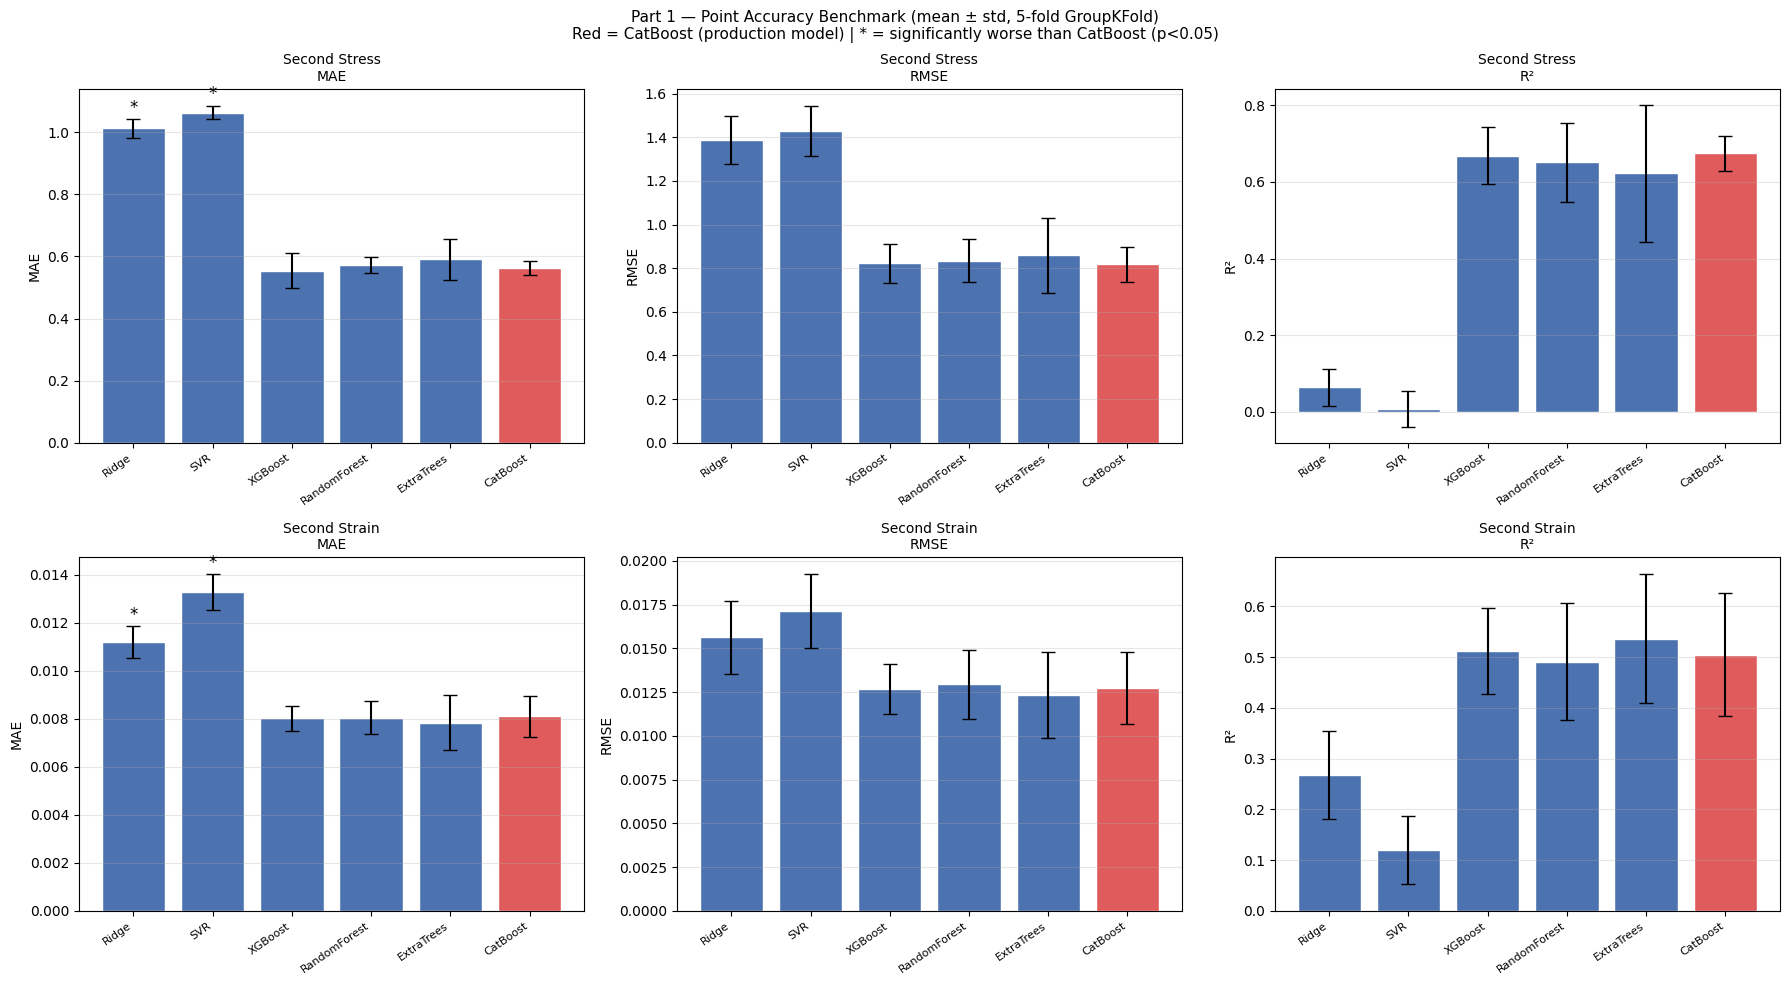

Saved → results/benchmark/part1_bars.png


In [27]:
# ─── Part 1 — Bar charts: MAE / RMSE / R² ────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_info = [("MAE_mean", "MAE_std", "MAE"),
                ("RMSE_mean","RMSE_std","RMSE"),
                ("R2_mean",  "R2_std",  "R²")]

for row_idx, target in enumerate(TARGETS):
    df_p1, _ = summarise_part1(target)
    df_p1    = df_p1.set_index("Model")
    for col_idx, (mean_col, std_col, label) in enumerate(metrics_info):
        ax = axes[row_idx, col_idx]
        vals = df_p1[mean_col].values
        errs = df_p1[std_col].values
        colors = ["#e05c5c" if m == "CatBoost" else "#4c72b0" for m in MODEL_NAMES]
        ax.bar(MODEL_NAMES, vals, yerr=errs, color=colors, capsize=5, edgecolor="white")
        ax.set_title(f"{target}\n{label}", fontsize=10)
        ax.set_ylabel(label)
        ax.set_xticklabels(MODEL_NAMES, rotation=35, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.3)
        # Mark significance (p<0.05) for CatBoost comparison
        if label == "MAE":
            df_tmp = df_p1.reset_index()
            for i, m in enumerate(MODEL_NAMES):
                p = df_tmp.loc[df_tmp["Model"]==m, "p_wilcoxon"].values
                if len(p) and not np.isnan(p[0]) and p[0] < 0.05 and m != "CatBoost":
                    ax.text(i, vals[i] + errs[i] + vals[i]*0.02, "*", ha="center", fontsize=12)

plt.suptitle("Part 1 — Point Accuracy Benchmark (mean ± std, 5-fold GroupKFold)\n"
             "Red = CatBoost (production model) | * = significantly worse than CatBoost (p<0.05)",
             fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "part1_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/benchmark/part1_bars.png")


---
## Part 2 — Mondrian CQR Regime-Wise Coverage & Width

All backends wrapped in identical Mondrian CQR (same outer folds, same 75/25 split).

**Regime cutoffs (production pipeline)**:
- Second Strain: NoPSH < 0.005, Bulk [0.005, 0.050), Tail ≥ 0.050
- Second Stress: Weak < 4.0 MPa, Mid [4.0, 5.13), Strong ≥ 5.13 MPa

Target coverage (α=0.20): **80%**
Report: overall + per-regime Cov80, Width80 (always as a pair).


In [28]:
# ─── Part 2 — Per-regime coverage and width ──────────────────────────────

def aggregate_regime_metrics(target):
    rnames = REGIME_NAMES[target]
    rows   = []
    for model_name in MODEL_NAMES:
        fold_rows = ALL_FOLD_RESULTS[model_name][target]
        # Concatenate all fold results
        y_all    = np.concatenate([fd["y_true"]  for fd in fold_rows])
        q50_all  = np.concatenate([fd["q50"]     for fd in fold_rows])
        lo_all   = np.concatenate([fd["lo"]      for fd in fold_rows])
        hi_all   = np.concatenate([fd["hi"]      for fd in fold_rows])
        reg_all  = np.concatenate([fd["regime"]  for fd in fold_rows])

        valid = ~np.isnan(q50_all)
        if valid.sum() == 0:
            row = {"Model": model_name,
                   "Overall_Cov80": np.nan, "Overall_Width80": np.nan, "Overall_MAE": np.nan}
            for rn in rnames:
                row[f"Cov_{rn}"] = np.nan; row[f"Width_{rn}"] = np.nan; row[f"n_{rn}"] = 0
            rows.append(row)
            continue

        y_all   = y_all[valid];   q50_all = q50_all[valid]
        lo_all  = lo_all[valid];  hi_all  = hi_all[valid]
        reg_all = reg_all[valid]

        overall = compute_metrics(y_all, q50_all, lo_all, hi_all)
        regime  = compute_regime_metrics(y_all, q50_all, lo_all, hi_all, reg_all, target)

        row = {"Model": model_name,
               "Overall_Cov80":  overall["Cov80"],
               "Overall_Width80": overall["Width80"],
               "Overall_MAE":    overall["MAE"]}
        for rn in rnames:
            r = regime.get(rn, {})
            row[f"Cov_{rn}"]   = r.get("Cov80",   np.nan)
            row[f"Width_{rn}"] = r.get("Width80",  np.nan)
            row[f"n_{rn}"]     = r.get("n",        0)
        rows.append(row)

    return pd.DataFrame(rows)


print("=" * 80)
for target in TARGETS:
    df_p2 = aggregate_regime_metrics(target)
    print(f"\n── Part 2: {target} ──")
    display(df_p2.round(4).set_index("Model"))
    out_path = RESULTS_DIR / f"mondrian_per_regime_{target.replace(' ','_').lower()}.csv"
    df_p2.to_csv(out_path, index=False)
    print(f"Saved → {out_path}")



── Part 2: Second Stress ──


,Overall_Cov80,Overall_Width80,Overall_MAE,Cov_Weak,Width_Weak,n_Weak,Cov_Mid,Width_Mid,n_Mid,Cov_Strong,Width_Strong,n_Strong
Model,,,,,,,,,,,,
Ridge,0.8043,3.6525,1.0132,0.7667,3.6697,90,1.0000,3.6644,95,0.6374,3.6230,91
SVR,0.8043,3.7467,1.0635,0.8444,3.6553,90,1.0000,3.7322,95,0.5604,3.8523,91
XGBoost,0.8696,2.4585,0.5549,0.8111,2.1618,90,0.9684,2.3108,95,0.8242,2.9062,91
RandomForest,0.8514,2.1806,0.5727,0.7778,1.8664,90,0.9579,2.2428,95,0.8132,2.4264,91
ExtraTrees,0.8659,2.1067,0.5902,0.8778,1.8938,90,0.9158,2.1133,95,0.8022,2.3104,91
CatBoost,0.8370,2.0146,0.5622,0.8000,1.9137,90,0.9263,2.1028,95,0.7802,2.0222,91


Saved → results/benchmark/mondrian_per_regime_second_stress.csv

── Part 2: Second Strain ──


,Overall_Cov80,Overall_Width80,Overall_MAE,Cov_NoPSH,Width_NoPSH,n_NoPSH,Cov_Bulk,Width_Bulk,n_Bulk,Cov_Tail,Width_Tail,n_Tail
Model,,,,,,,,,,,,
Ridge,0.8333,0.0473,0.0112,0.6197,0.0457,71,0.9727,0.0477,183,0.3636,0.0492,22
SVR,0.8116,0.0474,0.0133,0.5070,0.0452,71,0.9891,0.0476,183,0.3182,0.0534,22
XGBoost,0.8732,0.0316,0.0080,0.9014,0.0145,71,0.8907,0.0363,183,0.6364,0.0481,22
RandomForest,0.8877,0.0307,0.0080,0.8310,0.0085,71,0.9344,0.0376,183,0.6818,0.0446,22
ExtraTrees,0.8623,0.0278,0.0078,0.8592,0.0067,71,0.8907,0.0337,183,0.6364,0.0465,22
CatBoost,0.8623,0.0305,0.0081,0.9296,0.0114,71,0.8634,0.0364,183,0.6364,0.0436,22


Saved → results/benchmark/mondrian_per_regime_second_strain.csv


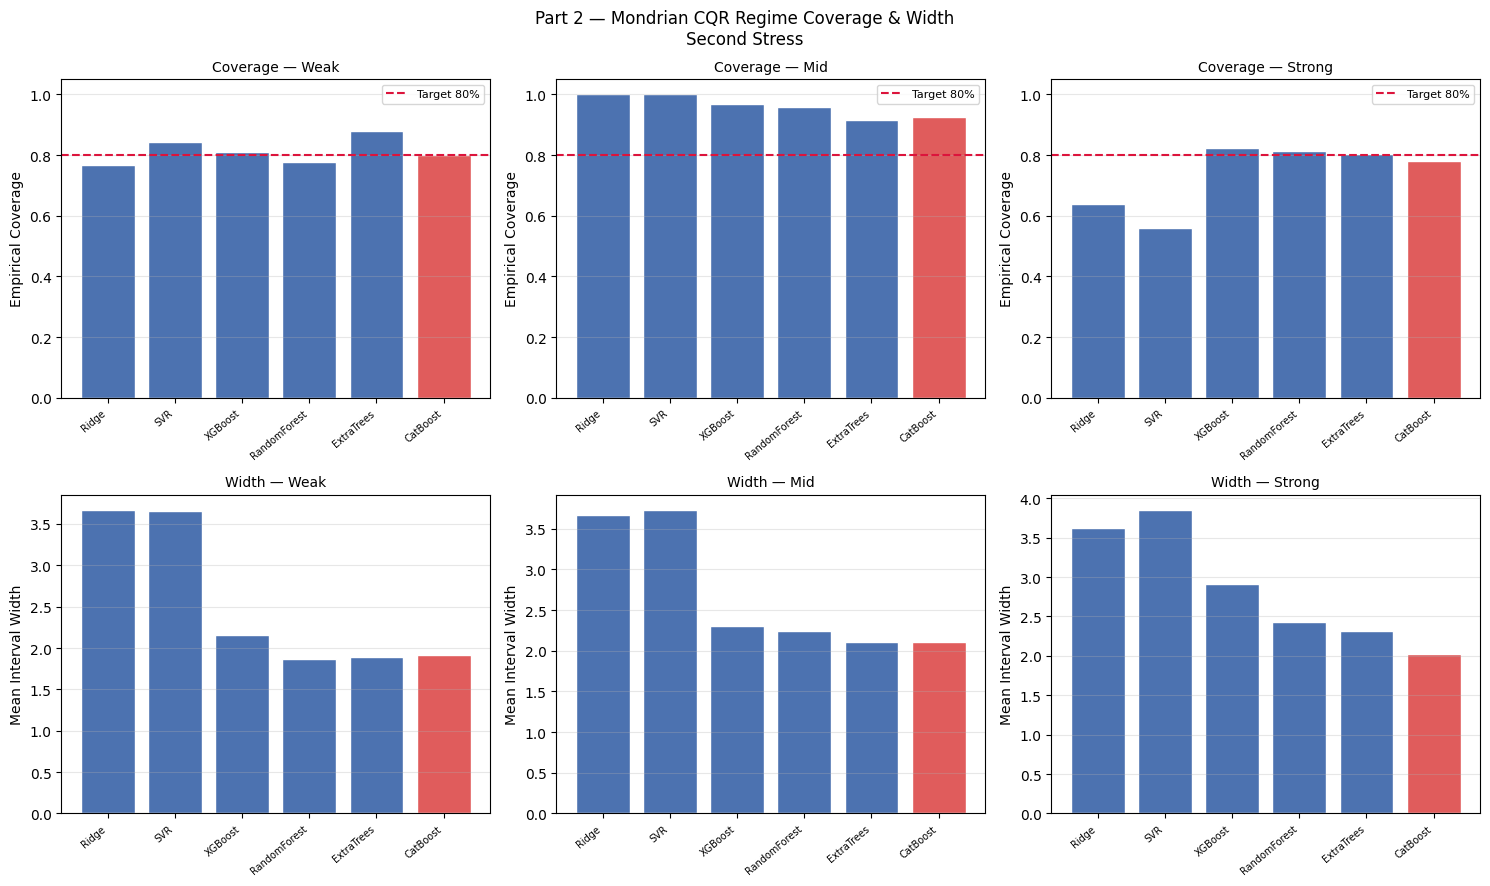

Saved → results/benchmark/part2_regime_second_stress.png


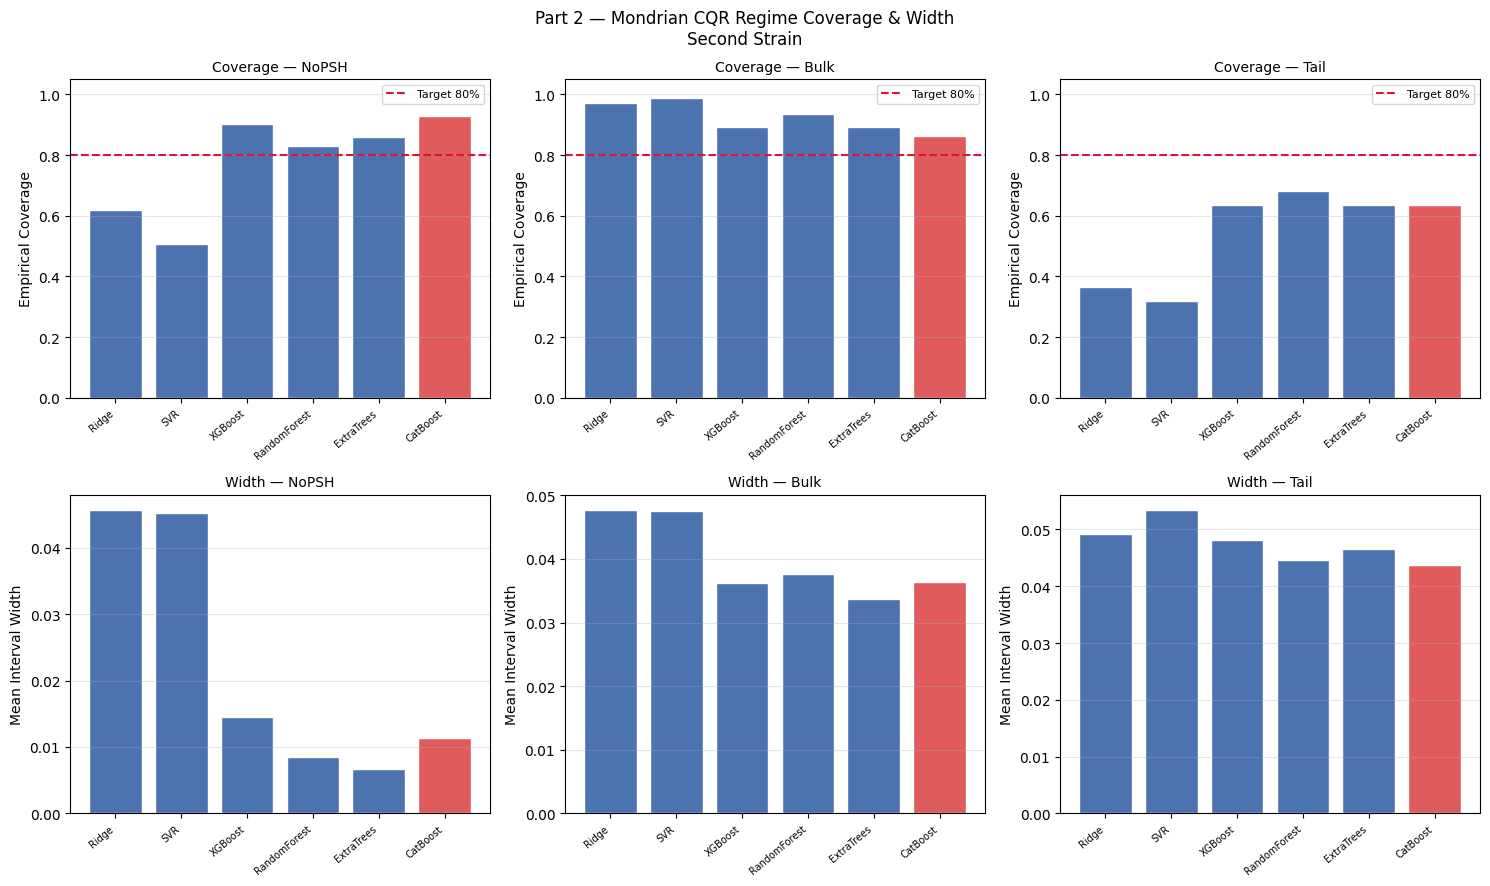

Saved → results/benchmark/part2_regime_second_strain.png


In [29]:
# ─── Part 2 — Two-row per-target: Coverage + Width ───────────────────────

for target in TARGETS:
    df_p2   = aggregate_regime_metrics(target).set_index("Model")
    rnames  = REGIME_NAMES[target]
    n_reg   = len(rnames)
    n_models= len(MODEL_NAMES)

    fig, axes = plt.subplots(2, n_reg, figsize=(5 * n_reg, 9), sharey=False)
    fig.suptitle(f"Part 2 — Mondrian CQR Regime Coverage & Width\n{target}",
                 fontsize=12)

    x   = np.arange(n_models)
    pal = ["#e05c5c" if m == "CatBoost" else "#4c72b0" for m in MODEL_NAMES]

    for ci, rn in enumerate(rnames):
        # Top row: coverage
        ax_cov = axes[0, ci]
        cov_vals = df_p2[f"Cov_{rn}"].values
        ax_cov.bar(x, cov_vals, color=pal, edgecolor="white")
        ax_cov.axhline(0.80, color="crimson", linestyle="--", lw=1.5, label="Target 80%")
        ax_cov.set_ylim(0, 1.05)
        ax_cov.set_title(f"Coverage — {rn}", fontsize=10)
        ax_cov.set_ylabel("Empirical Coverage")
        ax_cov.set_xticks(x); ax_cov.set_xticklabels(MODEL_NAMES, rotation=40, ha="right", fontsize=7)
        ax_cov.legend(fontsize=8)
        ax_cov.grid(axis="y", alpha=0.3)

        # Bottom row: width
        ax_wid = axes[1, ci]
        wid_vals = df_p2[f"Width_{rn}"].values
        ax_wid.bar(x, wid_vals, color=pal, edgecolor="white")
        ax_wid.set_title(f"Width — {rn}", fontsize=10)
        ax_wid.set_ylabel("Mean Interval Width")
        ax_wid.set_xticks(x); ax_wid.set_xticklabels(MODEL_NAMES, rotation=40, ha="right", fontsize=7)
        ax_wid.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fname = f"part2_regime_{target.replace(' ','_').lower()}.png"
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → results/benchmark/{fname}")


---
## Part 3 — CatBoost Calibration Ablation: QR vs CQR vs Mondrian CQR

Three configurations on the **same HP-optimized CatBoost** (HPs from Part 1 Fold 0):

| Config | Description |
|--------|-------------|
| **QR (plain)** | CatBoost q10/q50/q90, no conformal correction. `[lo, hi] = [q10, q90]` directly. |
| **CQR (vanilla)** | Single global qhat from calibration scores. |
| **Mondrian CQR** | Per-bin qhat (3 bins by q50 tertile). Production pipeline. |

**Key story**: QR under-covers overall; CQR fixes overall but is uneven per regime;
Mondrian CQR achieves uniform per-regime coverage.


In [30]:
# ─── Part 3 — CatBoost Calibration Ablation ──────────────────────────────

def run_ablation(target, alpha=ALPHA_DEFAULT):
    configs    = ["QR_plain", "CQR_vanilla", "Mondrian_CQR"]
    rnames     = REGIME_NAMES[target]
    all_results= {cfg: [] for cfg in configs}

    g          = GROUP_DFS[target]
    X_all      = g[FEATURES_32].values.astype(float)
    y_all      = g[target].values.astype(float)
    w_all      = g["sample_weight"].values.astype(float)
    groups_all = g["group_id"].values
    regime_all = g["regime"].values

    for fold_idx, (tr_idx, te_idx) in enumerate(OUTER_SPLITS[target]):
        # Use CatBoost best_params from Part 1
        fold_record = ALL_FOLD_RESULTS["CatBoost"][target][fold_idx]
        best_params = fold_record["best_params"]
        if "error" in best_params:
            continue

        X_tr, y_tr, w_tr = X_all[tr_idx], y_all[tr_idx], w_all[tr_idx]
        groups_tr         = groups_all[tr_idx]
        X_te, y_te        = X_all[te_idx], y_all[te_idx]
        regime_te         = regime_all[te_idx]

        fit_mask = get_fit_cal_split(groups_tr, outer_fold_idx=fold_idx)
        X_fit, y_fit, w_fit = X_tr[fit_mask],  y_tr[fit_mask],  w_tr[fit_mask]
        X_cal, y_cal        = X_tr[~fit_mask], y_tr[~fit_mask]

        # Full-train predictions on test
        q10_te, q50_te, q90_te = catboost_predict_q(
            X_tr, y_tr, w_tr, X_te, best_params, target
        )
        # Fit-only predictions on cal + q50 on test (for Mondrian binning)
        q10_cal, q50_cal, q90_cal = catboost_predict_q(
            X_fit, y_fit, w_fit, X_cal, best_params, target
        )
        _, q50_te_fit, _ = catboost_predict_q(
            X_fit, y_fit, w_fit, X_te, best_params, target
        )

        # ── Config 1: QR plain (no conformal) ────────────────────────────
        lo_qr = np.maximum(q10_te, 0)
        hi_qr = np.maximum(q90_te, 0)
        q50_qr= np.maximum(q50_te, 0)
        lo_qr = np.minimum(lo_qr, q50_qr)
        hi_qr = np.maximum(hi_qr, q50_qr)
        all_results["QR_plain"].append(
            {"y_true": y_te, "q50": q50_qr, "lo": lo_qr, "hi": hi_qr, "regime": regime_te}
        )

        # ── Config 2: CQR vanilla ─────────────────────────────────────────
        qhat_v = vanilla_cqr_calibrate(q10_cal, q90_cal, y_cal, alpha=alpha)
        lo_v, q50_v, hi_v = vanilla_cqr_apply(q10_te, q50_te, q90_te, qhat_v)
        all_results["CQR_vanilla"].append(
            {"y_true": y_te, "q50": q50_v, "lo": lo_v, "hi": hi_v, "regime": regime_te}
        )

        # ── Config 3: Mondrian CQR ────────────────────────────────────────
        bq33, bq67, qhat_m = mondrian_cqr_calibrate(
            q10_cal, q50_cal, q90_cal, y_cal, alpha=alpha
        )
        lo_m, q50_m, hi_m = mondrian_cqr_apply(
            q10_te, q50_te_fit, q90_te, bq33, bq67, qhat_m
        )
        all_results["Mondrian_CQR"].append(
            {"y_true": y_te, "q50": q50_m, "lo": lo_m, "hi": hi_m, "regime": regime_te}
        )

    # Aggregate across folds
    rows = []
    for cfg in configs:
        folds = all_results[cfg]
        y_all_c   = np.concatenate([f["y_true"] for f in folds])
        q50_all_c = np.concatenate([f["q50"]    for f in folds])
        lo_all_c  = np.concatenate([f["lo"]     for f in folds])
        hi_all_c  = np.concatenate([f["hi"]     for f in folds])
        reg_all_c = np.concatenate([f["regime"] for f in folds])

        overall = compute_metrics(y_all_c, q50_all_c, lo_all_c, hi_all_c)
        regime  = compute_regime_metrics(y_all_c, q50_all_c, lo_all_c, hi_all_c,
                                          reg_all_c, target)
        row = {"Config": cfg,
               "Overall_Cov80":   overall["Cov80"],
               "Overall_Width80": overall["Width80"]}
        for rn in rnames:
            r = regime.get(rn, {})
            row[f"Cov_{rn}"]   = r.get("Cov80",  np.nan)
            row[f"Width_{rn}"] = r.get("Width80", np.nan)
        rows.append(row)

    return pd.DataFrame(rows), configs, rnames


CKPT_P3 = RESULTS_DIR / "ckpt_ablation.pkl"

if CKPT_P3.exists():
    with open(CKPT_P3, "rb") as fh:
        ABLATION_DFS = pickle.load(fh)
    print(f"Resumed ablation checkpoint: {CKPT_P3}")
    for _t in ABLATION_DFS:
        print(f"  ✓ {_t} ablation (cached)")
else:
    ABLATION_DFS = {}

print("=" * 80)
for target in TARGETS:
    if target in ABLATION_DFS:
        df_p3 = ABLATION_DFS[target]
        print(f"\n── Part 3: {target} ── (cached)")
        display(df_p3.round(4).set_index("Config"))
        continue
    df_p3, configs, rnames = run_ablation(target)
    ABLATION_DFS[target] = df_p3
    with open(CKPT_P3, "wb") as fh:
        pickle.dump(ABLATION_DFS, fh)
    print(f"\n── Part 3: {target} ──")
    display(df_p3.round(4).set_index("Config"))

df_p3_stress = ABLATION_DFS["Second Stress"]
df_p3_strain = ABLATION_DFS["Second Strain"]
df_p3_combined = pd.concat([
    df_p3_stress.assign(Target="Second Stress"),
    df_p3_strain.assign(Target="Second Strain"),
])
df_p3_combined.to_csv(RESULTS_DIR / "catboost_calibration_ablation.csv", index=False)
print("Saved → results/benchmark/catboost_calibration_ablation.csv")



── Part 3: Second Stress ──


,Overall_Cov80,Overall_Width80,Cov_Weak,Width_Weak,Cov_Mid,Width_Mid,Cov_Strong,Width_Strong
Config,,,,,,,,
QR_plain,0.3406,0.5355,0.2556,0.4872,0.4632,0.5593,0.2967,0.5583
CQR_vanilla,0.8406,1.8551,0.8111,1.7806,0.9158,1.8870,0.7912,1.8957
Mondrian_CQR,0.8370,2.0146,0.8000,1.9137,0.9263,2.1028,0.7802,2.0222



── Part 3: Second Strain ──


,Overall_Cov80,Overall_Width80,Cov_NoPSH,Width_NoPSH,Cov_Bulk,Width_Bulk,Cov_Tail,Width_Tail
Config,,,,,,,,
QR_plain,0.2971,0.0061,0.2394,0.0022,0.3115,0.0070,0.3636,0.0107
CQR_vanilla,0.8551,0.0300,0.9437,0.0189,0.8525,0.0333,0.5909,0.0384
Mondrian_CQR,0.8623,0.0305,0.9296,0.0114,0.8634,0.0364,0.6364,0.0436


Saved → results/benchmark/catboost_calibration_ablation.csv


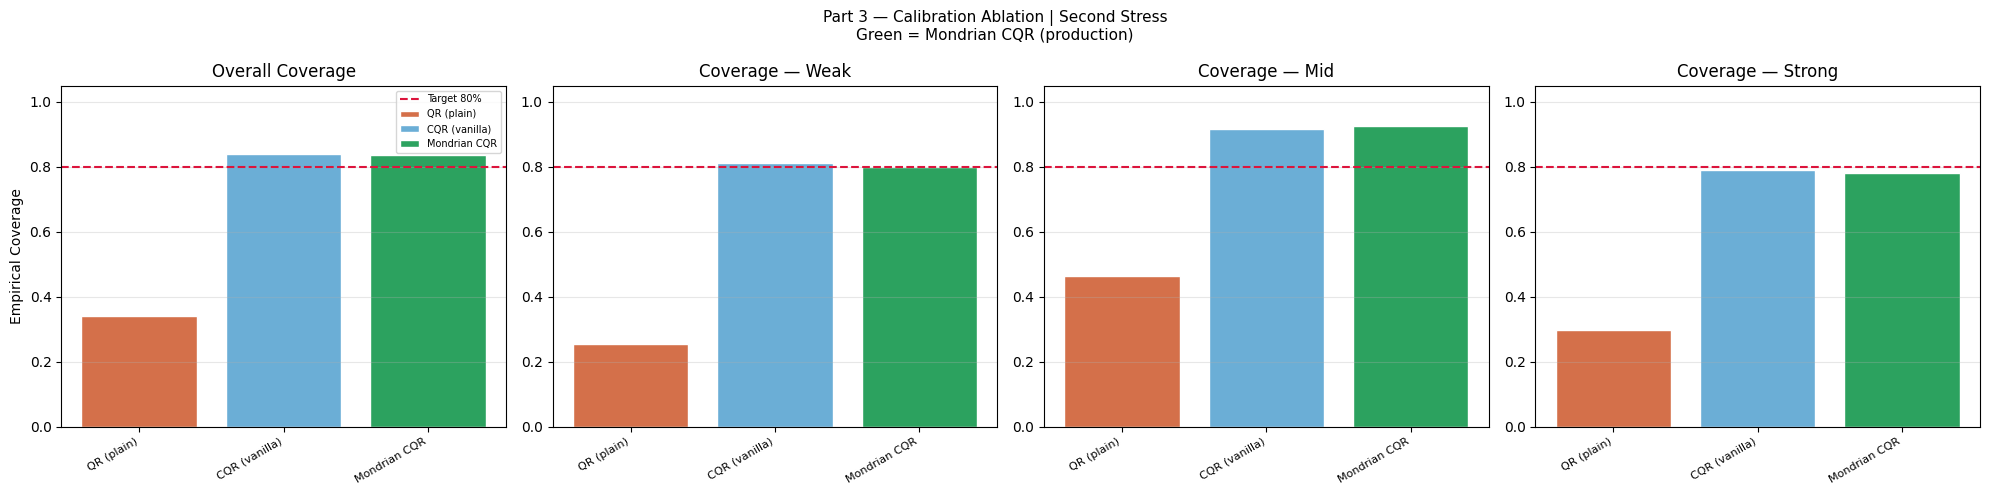

Saved → results/benchmark/part3_ablation_second_stress.png


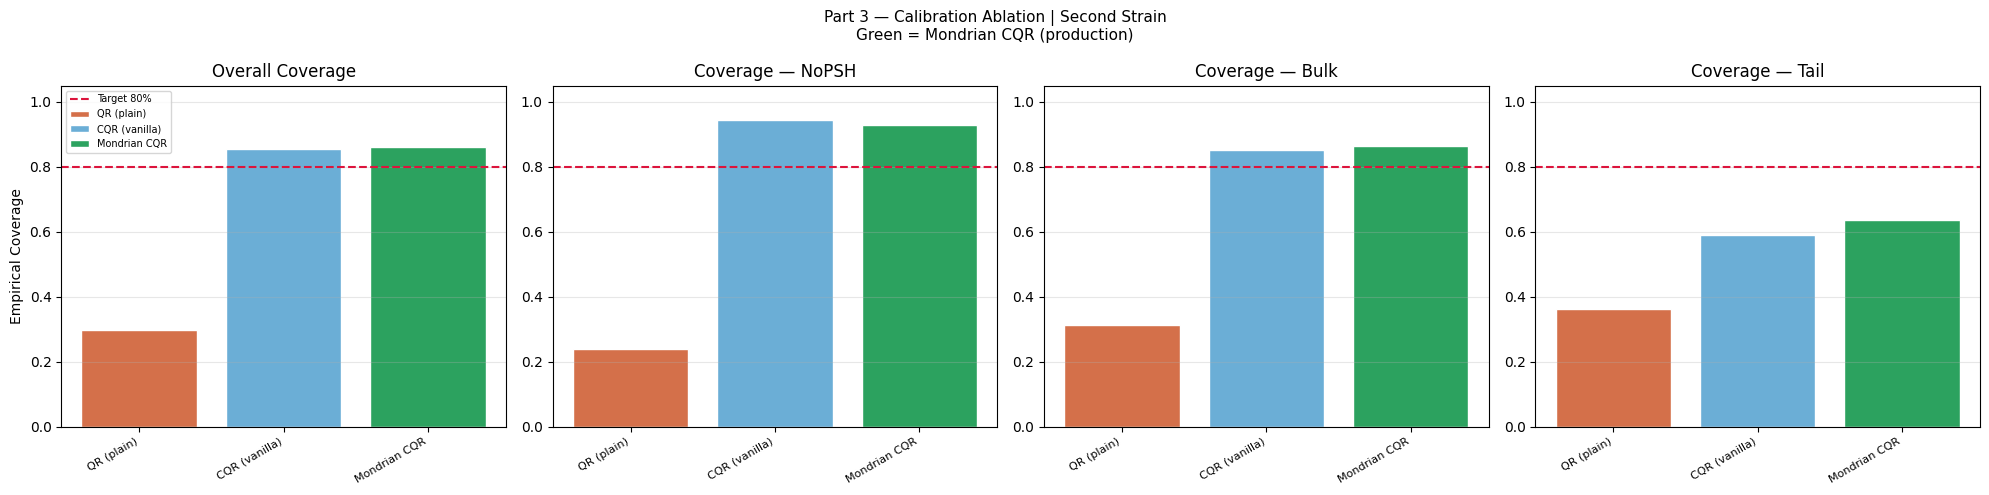

Saved → results/benchmark/part3_ablation_second_strain.png


In [31]:
# ─── Part 3 — Ablation bar chart: per-regime coverage ────────────────────

config_colors = {
    "QR_plain":     "#d4704a",
    "CQR_vanilla":  "#6baed6",
    "Mondrian_CQR": "#2ca25f",
}
config_labels = {
    "QR_plain":     "QR (plain)",
    "CQR_vanilla":  "CQR (vanilla)",
    "Mondrian_CQR": "Mondrian CQR",
}

for target in TARGETS:
    df_p3_plot, configs, rnames = run_ablation(target)
    n_reg   = len(rnames)
    x       = np.arange(len(configs))
    width   = 0.25
    offsets = np.linspace(-width, width, len(configs))

    fig, axes = plt.subplots(1, n_reg + 1, figsize=(5 * (n_reg + 1), 5))
    fig.suptitle(f"Part 3 — Calibration Ablation | {target}\n"
                 "Green = Mondrian CQR (production)", fontsize=11)

    # Overall coverage
    ax0 = axes[0]
    for ci, cfg in enumerate(configs):
        row = df_p3_plot[df_p3_plot["Config"] == cfg].iloc[0]
        ax0.bar(ci, row["Overall_Cov80"], color=config_colors[cfg],
                label=config_labels[cfg], edgecolor="white")
    ax0.axhline(0.80, color="crimson", linestyle="--", lw=1.5, label="Target 80%")
    ax0.set_title("Overall Coverage")
    ax0.set_ylabel("Empirical Coverage")
    ax0.set_ylim(0, 1.05)
    ax0.set_xticks(range(len(configs)))
    ax0.set_xticklabels([config_labels[c] for c in configs], rotation=30, ha="right", fontsize=8)
    ax0.legend(fontsize=7); ax0.grid(axis="y", alpha=0.3)

    # Per-regime coverage
    for ri, rn in enumerate(rnames):
        ax = axes[ri + 1]
        for ci, cfg in enumerate(configs):
            row = df_p3_plot[df_p3_plot["Config"] == cfg].iloc[0]
            ax.bar(ci, row[f"Cov_{rn}"], color=config_colors[cfg], edgecolor="white")
        ax.axhline(0.80, color="crimson", linestyle="--", lw=1.5)
        ax.set_title(f"Coverage — {rn}")
        ax.set_ylim(0, 1.05)
        ax.set_xticks(range(len(configs)))
        ax.set_xticklabels([config_labels[c] for c in configs], rotation=30, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fname = f"part3_ablation_{target.replace(' ','_').lower()}.png"
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → results/benchmark/{fname}")


---
## Part 4 — Alpha Sweep: Calibration Honesty Across Risk Levels

CatBoost + Mondrian CQR evaluated at α ∈ {0.05, 0.10, 0.15, 0.20, 0.25, 0.30}.

**Key plot**: Calibration curve (empirical coverage vs nominal coverage).
A well-calibrated method tracks the diagonal y = x.
Plain CQR is shown on the same axes for comparison.

This is **not** about finding the "best" α — α is a user-facing risk parameter.
We are showing that our method is *honest* across all risk levels.


In [32]:
# ─── Part 4 — Alpha sweep ─────────────────────────────────────────────────

ALPHA_GRID = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]


def run_alpha_sweep(target):
    g          = GROUP_DFS[target]
    X_all      = g[FEATURES_32].values.astype(float)
    y_all      = g[target].values.astype(float)
    w_all      = g["sample_weight"].values.astype(float)
    groups_all = g["group_id"].values
    regime_all = g["regime"].values
    rnames     = REGIME_NAMES[target]

    # Collect per-alpha, per-method data
    # {alpha: {method: {"y_true":..,"q10":..,"q50":..,"q90":..,"lo":..,"hi":..,"regime":..}}}
    sweep_data = {a: {"Mondrian": [], "CQR_vanilla": [], "QR_plain": []}
                  for a in ALPHA_GRID}

    for fold_idx, (tr_idx, te_idx) in enumerate(OUTER_SPLITS[target]):
        fold_record = ALL_FOLD_RESULTS["CatBoost"][target][fold_idx]
        best_params = fold_record["best_params"]
        if "error" in best_params:
            continue

        X_tr, y_tr, w_tr = X_all[tr_idx], y_all[tr_idx], w_all[tr_idx]
        X_te, y_te        = X_all[te_idx], y_all[te_idx]
        regime_te         = regime_all[te_idx]

        fit_mask = get_fit_cal_split(groups_tr=groups_all[tr_idx],
                                      outer_fold_idx=fold_idx)
        X_fit, y_fit, w_fit = X_tr[fit_mask],  y_tr[fit_mask],  w_tr[fit_mask]
        X_cal, y_cal        = X_tr[~fit_mask], y_tr[~fit_mask]

        q10_te, q50_te, q90_te = catboost_predict_q(
            X_tr, y_tr, w_tr, X_te, best_params, target
        )
        q10_cal, q50_cal, q90_cal = catboost_predict_q(
            X_fit, y_fit, w_fit, X_cal, best_params, target
        )
        _, q50_te_fit, _ = catboost_predict_q(
            X_fit, y_fit, w_fit, X_te, best_params, target
        )

        for alpha in ALPHA_GRID:
            # Mondrian CQR
            bq33, bq67, qhat_m = mondrian_cqr_calibrate(
                q10_cal, q50_cal, q90_cal, y_cal, alpha=alpha
            )
            lo_m, q50_m, hi_m = mondrian_cqr_apply(
                q10_te, q50_te_fit, q90_te, bq33, bq67, qhat_m
            )
            sweep_data[alpha]["Mondrian"].append(
                {"y_true": y_te, "q50": q50_m, "lo": lo_m, "hi": hi_m, "regime": regime_te}
            )

            # Vanilla CQR
            qhat_v = vanilla_cqr_calibrate(q10_cal, q90_cal, y_cal, alpha=alpha)
            lo_v, q50_v, hi_v = vanilla_cqr_apply(q10_te, q50_te, q90_te, qhat_v)
            sweep_data[alpha]["CQR_vanilla"].append(
                {"y_true": y_te, "q50": q50_v, "lo": lo_v, "hi": hi_v, "regime": regime_te}
            )

            # QR plain
            lo_qr = np.minimum(np.maximum(q10_te, 0), np.maximum(q50_te, 0))
            hi_qr = np.maximum(np.maximum(q90_te, 0), np.maximum(q50_te, 0))
            sweep_data[alpha]["QR_plain"].append(
                {"y_true": y_te, "q50": np.maximum(q50_te, 0),
                 "lo": lo_qr, "hi": hi_qr, "regime": regime_te}
            )

    # Aggregate
    rows = []
    for alpha in ALPHA_GRID:
        nominal = 1 - alpha
        for method in ["Mondrian", "CQR_vanilla", "QR_plain"]:
            folds = sweep_data[alpha][method]
            if not folds:
                continue
            y_c   = np.concatenate([f["y_true"]  for f in folds])
            lo_c  = np.concatenate([f["lo"]      for f in folds])
            hi_c  = np.concatenate([f["hi"]      for f in folds])
            q50_c = np.concatenate([f["q50"]     for f in folds])
            reg_c = np.concatenate([f["regime"]  for f in folds])

            cov_all = float(((y_c >= lo_c) & (y_c <= hi_c)).mean())
            wid_all = float(np.mean(hi_c - lo_c))

            row = {"Alpha": alpha, "Nominal_Coverage": nominal,
                   "Method": method,
                   "Empirical_Cov": cov_all, "Width": wid_all}

            rmed = compute_regime_metrics(y_c, q50_c, lo_c, hi_c, reg_c, target)
            for rn in rnames:
                r = rmed.get(rn, {})
                row[f"Cov_{rn}"]   = r.get("Cov80",  np.nan)
                row[f"Width_{rn}"] = r.get("Width80", np.nan)
            rows.append(row)

    return pd.DataFrame(rows)


CKPT_P4 = RESULTS_DIR / "ckpt_alpha_sweep.pkl"

if CKPT_P4.exists():
    with open(CKPT_P4, "rb") as fh:
        ALPHA_SWEEP_DFS = pickle.load(fh)
    print(f"Resumed alpha-sweep checkpoint: {CKPT_P4}")
    for _t in ALPHA_SWEEP_DFS:
        print(f"  ✓ {_t} alpha sweep (cached)")
else:
    ALPHA_SWEEP_DFS = {}

print("=" * 80)
for target in TARGETS:
    if target in ALPHA_SWEEP_DFS:
        df_p4 = ALPHA_SWEEP_DFS[target]
        print(f"\n── Part 4: {target} ── (cached)")
        df_m = df_p4[df_p4["Method"] == "Mondrian"][
            ["Alpha", "Nominal_Coverage", "Empirical_Cov", "Width"] +
            [f"Cov_{rn}" for rn in REGIME_NAMES[target]]
        ]
        display(df_m.round(4).set_index("Alpha"))
        continue
    df_p4 = run_alpha_sweep(target)
    ALPHA_SWEEP_DFS[target] = df_p4
    with open(CKPT_P4, "wb") as fh:
        pickle.dump(ALPHA_SWEEP_DFS, fh)
    print(f"\n── Part 4: {target} ── (Mondrian CQR only)")
    df_m = df_p4[df_p4["Method"] == "Mondrian"][
        ["Alpha", "Nominal_Coverage", "Empirical_Cov", "Width"] +
        [f"Cov_{rn}" for rn in REGIME_NAMES[target]]
    ]
    display(df_m.round(4).set_index("Alpha"))

df_sweep_all = pd.concat([
    ALPHA_SWEEP_DFS["Second Stress"].assign(Target="Second Stress"),
    ALPHA_SWEEP_DFS["Second Strain"].assign(Target="Second Strain"),
])
df_sweep_all.to_csv(RESULTS_DIR / "alpha_sweep.csv", index=False)
print("\nSaved → results/benchmark/alpha_sweep.csv")



── Part 4: Second Stress ── (Mondrian CQR only)


,Nominal_Coverage,Empirical_Cov,Width,Cov_Weak,Cov_Mid,Cov_Strong
Alpha,,,,,,
0.05,0.95,0.9638,4.0591,0.9778,0.9789,0.9341
0.10,0.90,0.9348,3.0809,0.9556,0.9579,0.8901
0.15,0.85,0.8841,2.3776,0.8667,0.9474,0.8352
0.20,0.80,0.8370,2.0146,0.8000,0.9263,0.7802
0.25,0.75,0.8261,1.7832,0.8000,0.9158,0.7582
0.30,0.70,0.7681,1.5806,0.7111,0.8842,0.7033



── Part 4: Second Strain ── (Mondrian CQR only)


,Nominal_Coverage,Empirical_Cov,Width,Cov_NoPSH,Cov_Bulk,Cov_Tail
Alpha,,,,,,
0.05,0.95,0.9710,0.0582,0.9859,0.9891,0.7727
0.10,0.90,0.9493,0.0509,0.9718,0.9672,0.7273
0.15,0.85,0.8986,0.0350,0.9577,0.9071,0.6364
0.20,0.80,0.8623,0.0305,0.9296,0.8634,0.6364
0.25,0.75,0.8478,0.0276,0.9155,0.8470,0.6364
0.30,0.70,0.8297,0.0249,0.8732,0.8361,0.6364



Saved → results/benchmark/alpha_sweep.csv


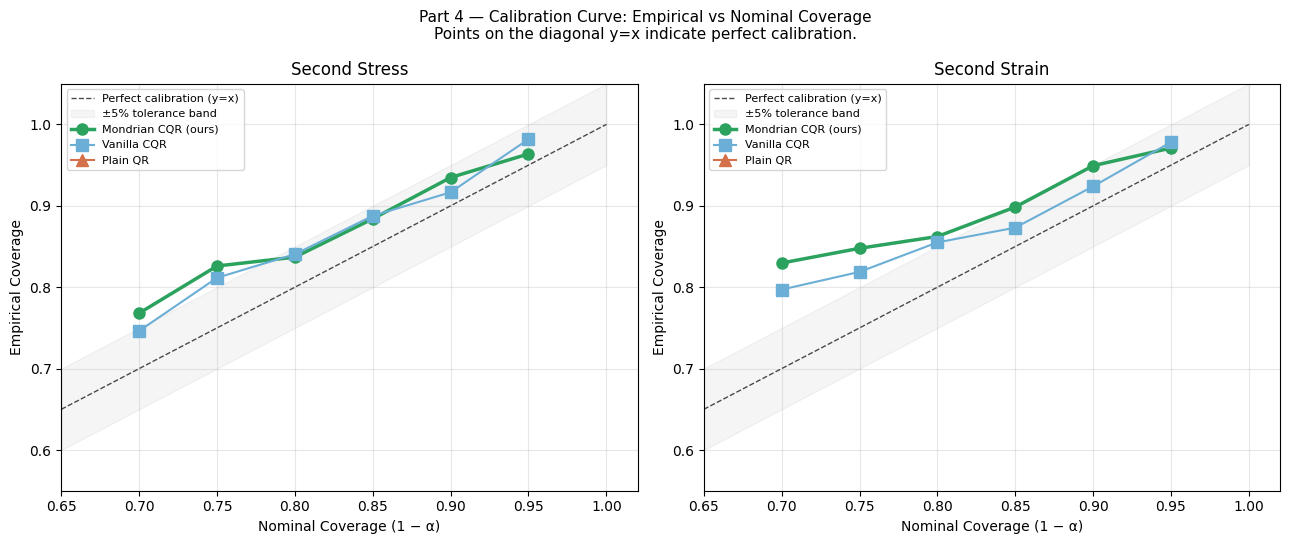

Saved → results/benchmark/part4_calibration_curve.png


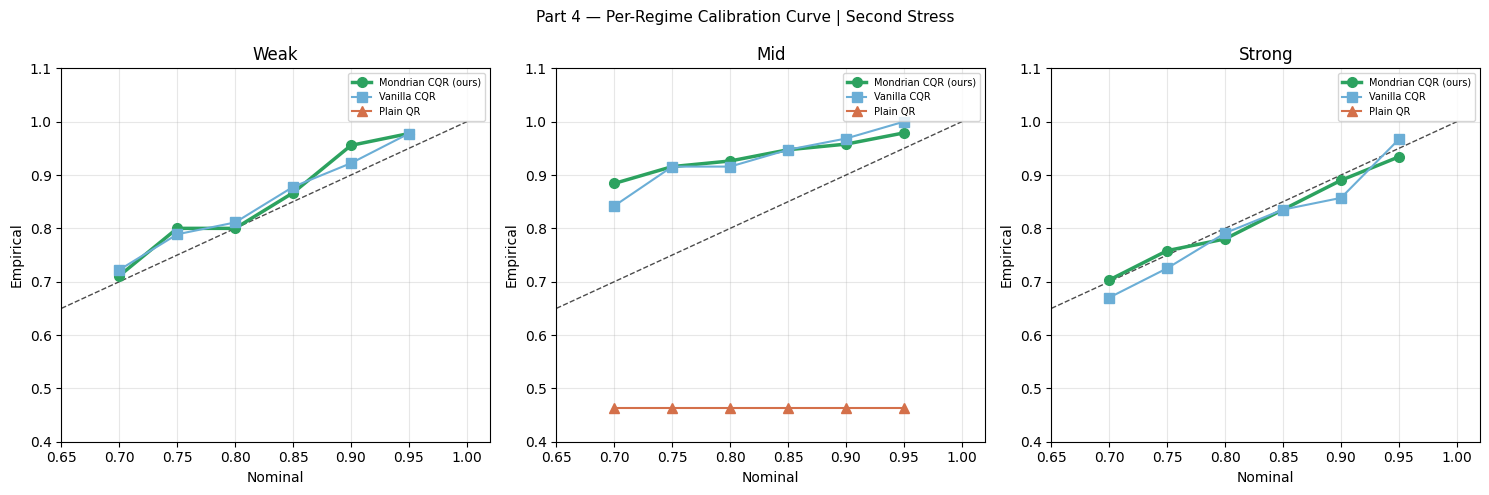

Saved → results/benchmark/part4_regime_curve_second_stress.png


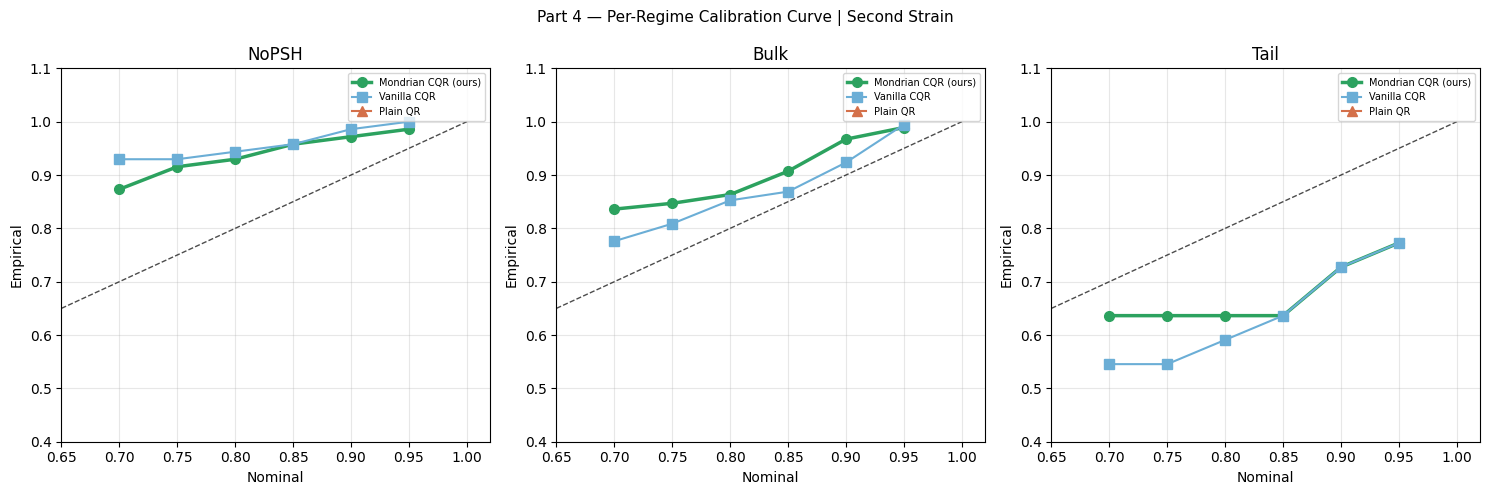

Saved → results/benchmark/part4_regime_curve_second_strain.png


In [33]:
# ─── Part 4 — Calibration curve ──────────────────────────────────────────

method_styles = {
    "Mondrian":    {"color": "#2ca25f", "marker": "o", "label": "Mondrian CQR (ours)", "lw": 2.5},
    "CQR_vanilla": {"color": "#6baed6", "marker": "s", "label": "Vanilla CQR",         "lw": 1.5},
    "QR_plain":    {"color": "#d4704a", "marker": "^", "label": "Plain QR",             "lw": 1.5},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("Part 4 — Calibration Curve: Empirical vs Nominal Coverage\n"
             "Points on the diagonal y=x indicate perfect calibration.", fontsize=11)

for col_idx, target in enumerate(TARGETS):
    ax  = axes[col_idx]
    df4 = ALPHA_SWEEP_DFS[target]

    diag = np.linspace(0.65, 1.0, 100)
    ax.plot(diag, diag, "k--", lw=1, label="Perfect calibration (y=x)", alpha=0.7)
    ax.fill_between(diag, diag - 0.05, diag + 0.05, alpha=0.08, color="gray",
                    label="±5% tolerance band")

    for method, sty in method_styles.items():
        sub = df4[df4["Method"] == method].sort_values("Nominal_Coverage")
        ax.plot(sub["Nominal_Coverage"], sub["Empirical_Cov"],
                marker=sty["marker"], color=sty["color"], lw=sty["lw"],
                label=sty["label"], markersize=8)

    ax.set_xlim(0.65, 1.02); ax.set_ylim(0.55, 1.05)
    ax.set_xlabel("Nominal Coverage (1 − α)")
    ax.set_ylabel("Empirical Coverage")
    ax.set_title(target)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "part4_calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/benchmark/part4_calibration_curve.png")

# ── Per-regime calibration curves (one per target) ────────────────────────
for target in TARGETS:
    df4    = ALPHA_SWEEP_DFS[target]
    rnames = REGIME_NAMES[target]
    fig, axes = plt.subplots(1, len(rnames), figsize=(5 * len(rnames), 5))
    fig.suptitle(f"Part 4 — Per-Regime Calibration Curve | {target}", fontsize=11)

    for ri, rn in enumerate(rnames):
        ax = axes[ri]
        diag = np.linspace(0.65, 1.0, 100)
        ax.plot(diag, diag, "k--", lw=1, alpha=0.7)

        for method, sty in method_styles.items():
            sub = df4[df4["Method"] == method].sort_values("Nominal_Coverage")
            col = f"Cov_{rn}"
            if col in sub.columns:
                ax.plot(sub["Nominal_Coverage"], sub[col],
                        marker=sty["marker"], color=sty["color"],
                        lw=sty["lw"], label=sty["label"], markersize=7)

        ax.set_xlim(0.65, 1.02); ax.set_ylim(0.40, 1.10)
        ax.set_title(rn); ax.set_xlabel("Nominal"); ax.set_ylabel("Empirical")
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

    plt.tight_layout()
    fname = f"part4_regime_curve_{target.replace(' ','_').lower()}.png"
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → results/benchmark/{fname}")


In [34]:
# ─── Final Summary ────────────────────────────────────────────────────────

print("=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)

for target in TARGETS:
    print(f"\n── {target} ──")

    # Part 1: CatBoost point accuracy
    cb_folds = ALL_FOLD_RESULTS["CatBoost"][target]
    cb_maes  = [mean_absolute_error(fd["y_true"], fd["q50"])
                for fd in cb_folds if not np.all(np.isnan(fd["q50"]))]
    print(f"  Part 1 CatBoost MAE: {np.mean(cb_maes):.4f} ± {np.std(cb_maes):.4f}")

    # Part 1: all models
    for m in MODEL_NAMES:
        fd_list = ALL_FOLD_RESULTS[m][target]
        maes    = [mean_absolute_error(fd["y_true"], fd["q50"])
                   for fd in fd_list if not np.all(np.isnan(fd["q50"]))]
        if maes:
            print(f"  {m:15s} MAE: {np.mean(maes):.4f} ± {np.std(maes):.4f}")

print("\n")
print("Output files:")
for p in sorted(RESULTS_DIR.rglob("*")):
    if p.is_file() and p.suffix in (".csv", ".png", ".pkl"):
        print(f"  {p}")
print("\nBenchmark study complete.")


RESULTS SUMMARY

── Second Stress ──
  Part 1 CatBoost MAE: 0.5621 ± 0.0221
  Ridge           MAE: 1.0131 ± 0.0303
  SVR             MAE: 1.0634 ± 0.0221
  XGBoost         MAE: 0.5547 ± 0.0556
  RandomForest    MAE: 0.5727 ± 0.0244
  ExtraTrees      MAE: 0.5904 ± 0.0673
  CatBoost        MAE: 0.5621 ± 0.0221

── Second Strain ──
  Part 1 CatBoost MAE: 0.0081 ± 0.0009
  Ridge           MAE: 0.0112 ± 0.0007
  SVR             MAE: 0.0133 ± 0.0008
  XGBoost         MAE: 0.0080 ± 0.0005
  RandomForest    MAE: 0.0080 ± 0.0007
  ExtraTrees      MAE: 0.0078 ± 0.0011
  CatBoost        MAE: 0.0081 ± 0.0009


Output files:
  results/benchmark/alpha_sweep.csv
  results/benchmark/catboost_calibration_ablation.csv
  results/benchmark/ckpt_ablation.pkl
  results/benchmark/ckpt_all_fold_results.pkl
  results/benchmark/ckpt_alpha_sweep.pkl
  results/benchmark/mondrian_per_regime_second_strain.csv
  results/benchmark/mondrian_per_regime_second_stress.csv
  results/benchmark/optuna_studies/ExtraTrees_Sec